# Task 4: Mining Insights from Customer Feedback
## G43 — Full Analysis Pipeline

**Structure:**
1. **EDA** — Data exploration & corpus understanding
2. **Preprocessing** — Text cleaning pipeline
3. **Part 1: Clustering Analysis** — KMeans/HAC on TF-IDF & SBERT
4. **Part 2: Topic Modelling & Sentiment** — Two design axes
5. **Evaluation** — Consistency, coherence, alignment
6. **Actionable Insights** — Final findings


In [1]:
%pip install kagglehub contractions gensim sentence-transformers nltk bertopic vaderSentiment textblob -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub
import numpy as np
import pandas as pd
import os, re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLP
import nltk
import contractions
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from gensim.parsing.preprocessing import STOPWORDS
from sentence_transformers import SentenceTransformer
import gensim.downloader as api

# ML
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.decomposition import PCA, LatentDirichletAllocation
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr, spearmanr

# Sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# Settings
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 20)

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

print("Loading models...")
skipgram_model = api.load('word2vec-google-news-300')
sbert = SentenceTransformer('all-MiniLM-L6-v2')
print("Models loaded.")


Loading models...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded.


# 1. Data Loading & Exploratory Data Analysis

In [3]:
download_path = kagglehub.dataset_download("suraj520/customer-support-ticket-dataset")
csv_path = os.path.join(download_path, "customer_support_tickets.csv")
df = pd.read_csv(csv_path, encoding='utf-8')
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset: 8469 rows, 17 columns


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


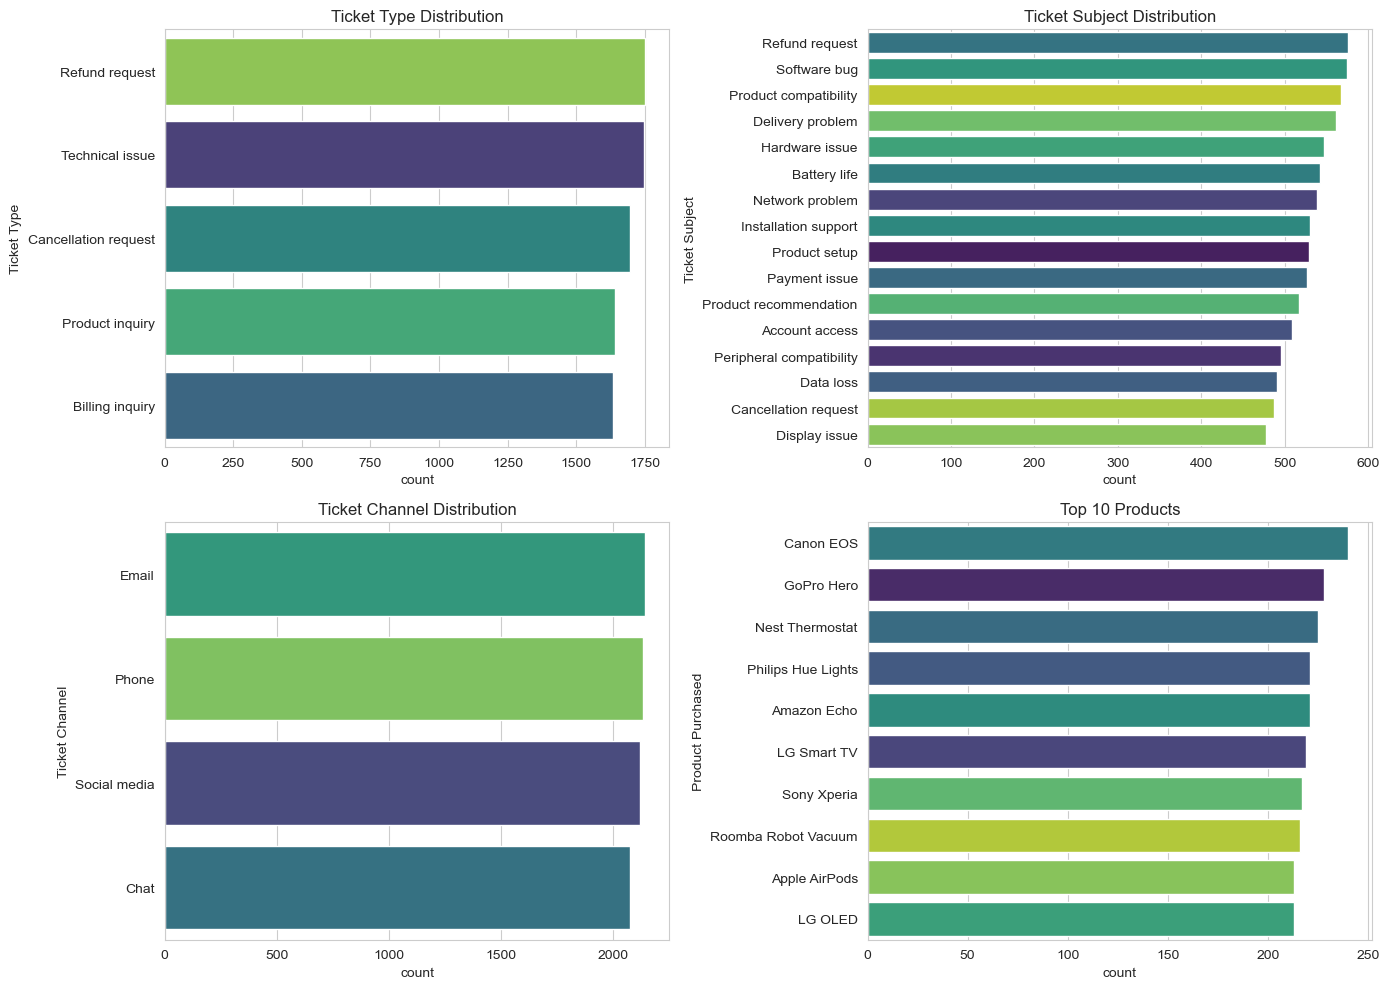

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(data=df, y='Ticket Type', order=df['Ticket Type'].value_counts().index,
              hue='Ticket Type', legend=False, palette='viridis', ax=axes[0,0])
axes[0,0].set_title('Ticket Type Distribution')
sns.countplot(data=df, y='Ticket Subject', order=df['Ticket Subject'].value_counts().index,
              hue='Ticket Subject', legend=False, palette='viridis', ax=axes[0,1])
axes[0,1].set_title('Ticket Subject Distribution')
sns.countplot(data=df, y='Ticket Channel', order=df['Ticket Channel'].value_counts().index,
              hue='Ticket Channel', legend=False, palette='viridis', ax=axes[1,0])
axes[1,0].set_title('Ticket Channel Distribution')
top_products = df['Product Purchased'].value_counts().head(10).index
sns.countplot(data=df[df['Product Purchased'].isin(top_products)], y='Product Purchased',
              order=top_products, hue='Product Purchased', legend=False, palette='viridis', ax=axes[1,1])
axes[1,1].set_title('Top 10 Products')
plt.tight_layout()
plt.show()


In [5]:
print("=== Ticket Description Corpus Stats ===")
df['word_count'] = df['Ticket Description'].str.split().str.len()
print(f"Total tickets: {len(df)}")
print(f"Mean word count: {df['word_count'].mean():.1f}")
print(f"Template placeholders: {df['Ticket Description'].str.contains('{').sum()} / {len(df)} (100%)")
print(f"Social media handles: {df['Ticket Description'].str.contains(r'@\w+', regex=True).sum()}")
print(f"Missing Resolution: {df['Resolution'].isnull().sum()} ({df['Resolution'].isnull().mean()*100:.1f}%)")
print("\n=== Cross-tab: Ticket Type vs Priority ===")
print(pd.crosstab(df['Ticket Type'], df['Ticket Priority']))


=== Ticket Description Corpus Stats ===
Total tickets: 8469
Mean word count: 46.5
Template placeholders: 8469 / 8469 (100%)
Social media handles: 203
Missing Resolution: 5700 (67.3%)

=== Cross-tab: Ticket Type vs Priority ===
Ticket Priority       Critical  High  Low  Medium
Ticket Type                                      
Billing inquiry            420   382  398     434
Cancellation request       423   398  414     460
Product inquiry            403   399  398     441
Refund request             444   448  440     420
Technical issue            439   458  413     437


In [6]:
print("=== Sample Ticket Descriptions ===\n")
for i in range(5):
    print(f"--- Ticket {i} (Type: {df['Ticket Type'].iloc[i]}) ---")
    print(df['Ticket Description'].iloc[i][:300])
    print()


=== Sample Ticket Descriptions ===

--- Ticket 0 (Type: Technical issue) ---
I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.

--- Ticket 1 (Type: Technical issue) ---
I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.

--- Ticket 2 (Type: Technical issue) ---
I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.

1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging prope

In [7]:
def get_top_ngrams(df, ticket_type, n=2, top_k=8):
    texts = ' '.join(df[df['Ticket Type'] == ticket_type]['Ticket Description']).lower().split()
    return Counter(ngrams(texts, n)).most_common(top_k)

print("=== Top Bigrams by Ticket Type (Raw Text) ===")
for tt in df['Ticket Type'].unique():
    bigrams = get_top_ngrams(df, tt, n=2, top_k=5)
    formatted = [(' '.join(bg), c) for bg, c in bigrams]
    print(f"{tt:25s} → {formatted}")


=== Top Bigrams by Ticket Type (Raw Text) ===
Technical issue           → [('the {product_purchased}.', 1432), ('with the', 1338), ('issue with', 1330), ("i'm having", 1318), ('an issue', 1307)]
Billing inquiry           → [('the {product_purchased}.', 1295), ('with the', 1250), ('issue with', 1227), ("i'm having", 1212), ('an issue', 1207)]
Cancellation request      → [('the {product_purchased}.', 1351), ('with the', 1287), ('issue with', 1281), ("i'm having", 1278), ('an issue', 1257)]
Product inquiry           → [('the {product_purchased}.', 1295), ('issue with', 1234), ('with the', 1219), ("i'm having", 1212), ('an issue', 1195)]
Refund request            → [('the {product_purchased}.', 1390), ('issue with', 1322), ('with the', 1310), ("i'm having", 1302), ('an issue', 1293)]


# 2. Text Preprocessing Pipeline

In [8]:
def to_lower(text):
    return str(text).lower()

def expand_contractions_fn(text):
    return contractions.fix(text)

def replace_product_placeholder(text):
    return re.sub(r'\{product_purchased\}', 'PRODUCT', text, flags=re.IGNORECASE)

def remove_noise(text):
    text = re.sub(r'\S+@\S+\.\S+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\b\d{5}\b', '', text)
    text = re.sub(r'\b\d+(\.\d+)+\b', '', text)
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize_text(text):
    return word_tokenize(text)

custom_stopwords = frozenset([
    'please', 'help', 'thank', 'thanks', 'hi', 'hello',
    'dear', 'regards', 'appreciate', 'kindly',
    'issue', 'problem', 'assist', 'experiencing', 'need',
    'having', 'facing', 'would', 'could', 'get', 'got',
    'also', 'using', 'use', 'let', 'know', 'like', 'one',
    'set', 'add',
    'try', 'tried', 'trying', 'want', 'wanted',
    'work', 'working', 'resolve', 'resolved',
    'look', 'looking', 'go', 'going', 'keep',
    'take', 'make', 'making', 'able', 'unable',
    'receive', 'received', 'provide', 'provided',
    'product', 'customer', 'service', 'support',
    'team', 'response', 'request', 'information',
    'time', 'day', 'week',
    'since', 'still', 'even', 'much',
    'really', 'already', 'just', 'yet',
    'update', 'device', 'data', 'software', 'account',
    'step', 'persists', 'perform', 'troubleshoot', 'contact',
    'start', 'notice', 'fine', 'check', 'multiple',
    'available', 'productivity', 'reset', 'option',
    'change', 'say', 'possible', 'specific', 'action',
])

def remove_stopwords_all(tokens):
    return [w for w in tokens if w not in STOPWORDS and w not in custom_stopwords]

def filter_short_tokens(tokens, min_len=3):
    return [t for t in tokens if len(t) >= min_len]

lemmatizer = WordNetLemmatizer()
tag_map = {'J': 'a', 'V': 'v', 'N': 'n', 'R': 'r'}

def lemmatize_tokens(tokens):
    tagged = pos_tag(tokens)
    return [lemmatizer.lemmatize(token, tag_map.get(tag[0].upper(), 'n'))
            for token, tag in tagged]

print("Preprocessing functions defined.")


Preprocessing functions defined.


In [9]:
bow_vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=5000, max_df=0.85)
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=3, max_df=0.85)

def vectorize_skipgram(token_lists):
    embeddings = []
    for tokens in token_lists:
        vecs = [skipgram_model[t] for t in tokens if t in skipgram_model]
        embeddings.append(np.mean(vecs, axis=0) if vecs else np.zeros(300))
    return np.array(embeddings)

def preprocess_text(df):
    text = df['Ticket Description'].copy()
    text = text.apply(to_lower)
    text = text.apply(expand_contractions_fn)
    text = text.apply(replace_product_placeholder)
    text = text.apply(remove_noise)
    sbert_text = text.copy()
    tokens = text.apply(tokenize_text)
    tokens = tokens.apply(remove_stopwords_all)
    tokens = tokens.apply(filter_short_tokens)
    tokens = tokens.apply(lemmatize_tokens)
    return tokens, sbert_text

def build_all_representations(df):
    tokens, sbert_text = preprocess_text(df)
    clean_text = tokens.apply(lambda t: ' '.join(t))
    print("Building BoW...", end=" ")
    X_bow = bow_vectorizer.fit_transform(clean_text)
    print(f"shape: {X_bow.shape}")
    print("Building TF-IDF...", end=" ")
    X_tfidf = tfidf_vectorizer.fit_transform(clean_text)
    print(f"shape: {X_tfidf.shape}")
    print("Building Skipgram...", end=" ")
    X_skipgram = vectorize_skipgram(tokens.tolist())
    print(f"shape: {X_skipgram.shape}")
    print("Building SBERT...", end=" ")
    X_sbert = sbert.encode(sbert_text.tolist(), show_progress_bar=True, batch_size=64)
    print(f"shape: {X_sbert.shape}")
    return X_bow, X_tfidf, X_skipgram, X_sbert, tokens, clean_text

X_bow, X_tfidf, X_skipgram, X_sbert, tokens, clean_text = build_all_representations(df)


Building BoW... shape: (8469, 5000)
Building TF-IDF... shape: (8469, 3642)
Building Skipgram... shape: (8469, 300)
Building SBERT... 

Batches:   0%|          | 0/133 [00:00<?, ?it/s]

shape: (8469, 384)


In [10]:
print("=== Top 5 TF-IDF Features per Ticket Type ===")
feature_names = tfidf_vectorizer.get_feature_names_out()
for ticket_type in df['Ticket Type'].unique():
    mask = (df['Ticket Type'] == ticket_type).values
    type_mean = X_tfidf[mask].mean(axis=0).A1
    top_5 = type_mean.argsort()[-5:][::-1]
    words = [feature_names[i] for i in top_5]
    print(f"  {ticket_type:25s} → {words}")


=== Top 5 TF-IDF Features per Ticket Type ===
  Technical issue           → ['step', 'time', 'start', 'update', 'notice']
  Billing inquiry           → ['step', 'time', 'notice', 'start', 'update']
  Cancellation request      → ['step', 'time', 'start', 'update', 'notice']
  Product inquiry           → ['step', 'time', 'update', 'start', 'guide']
  Refund request            → ['step', 'start', 'notice', 'update', 'error']


# 3. Representation Comparison — PCA Visualisation

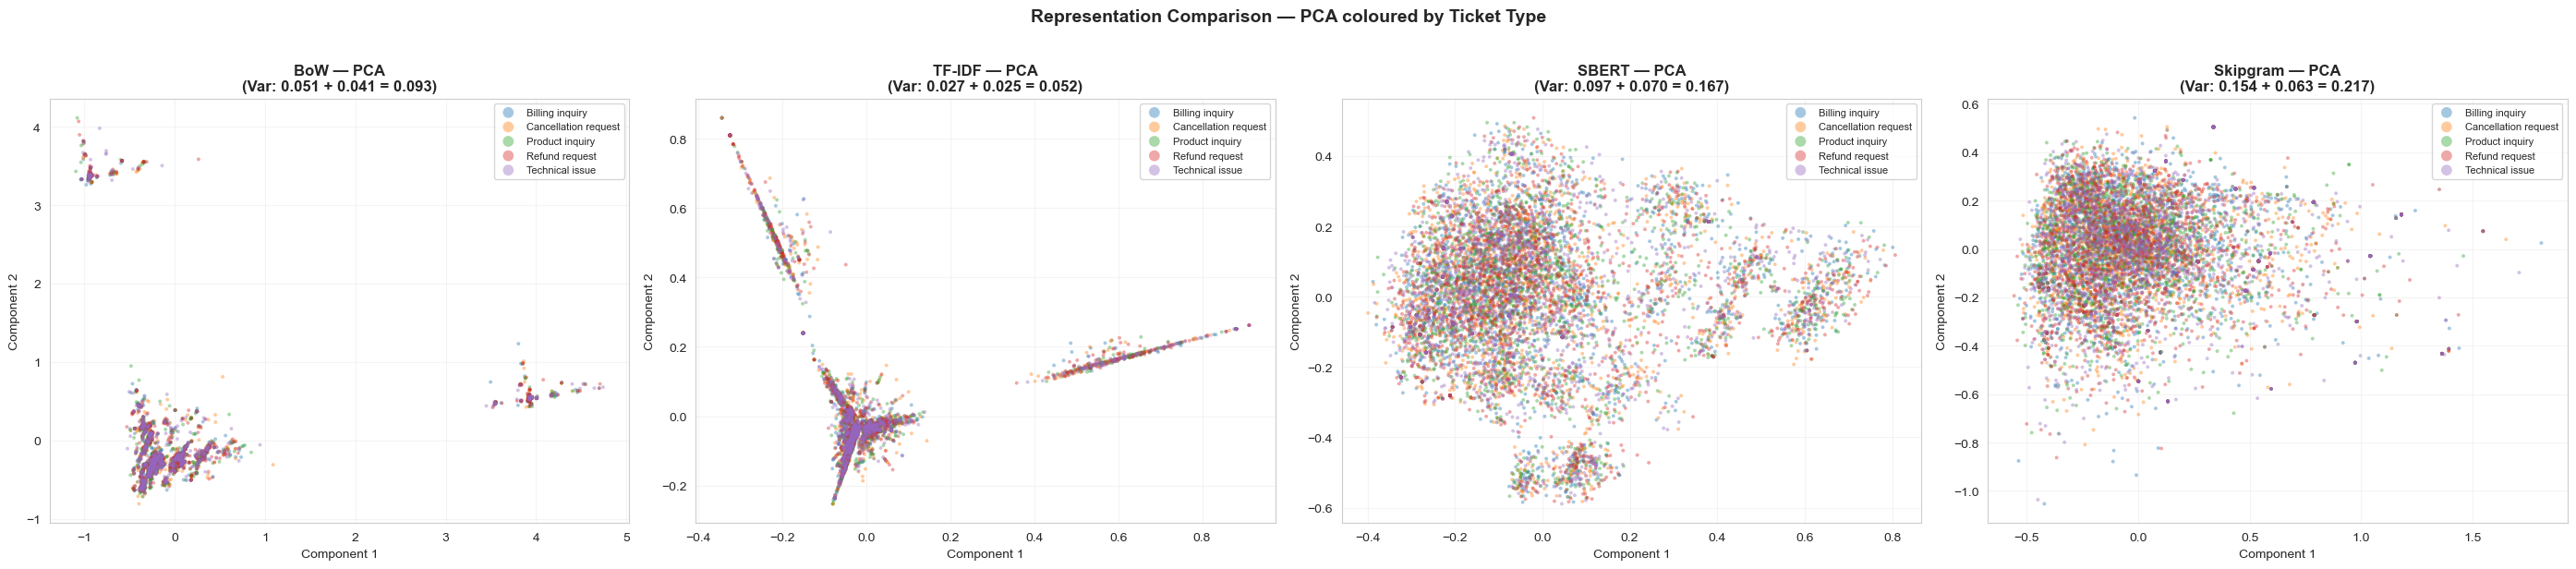

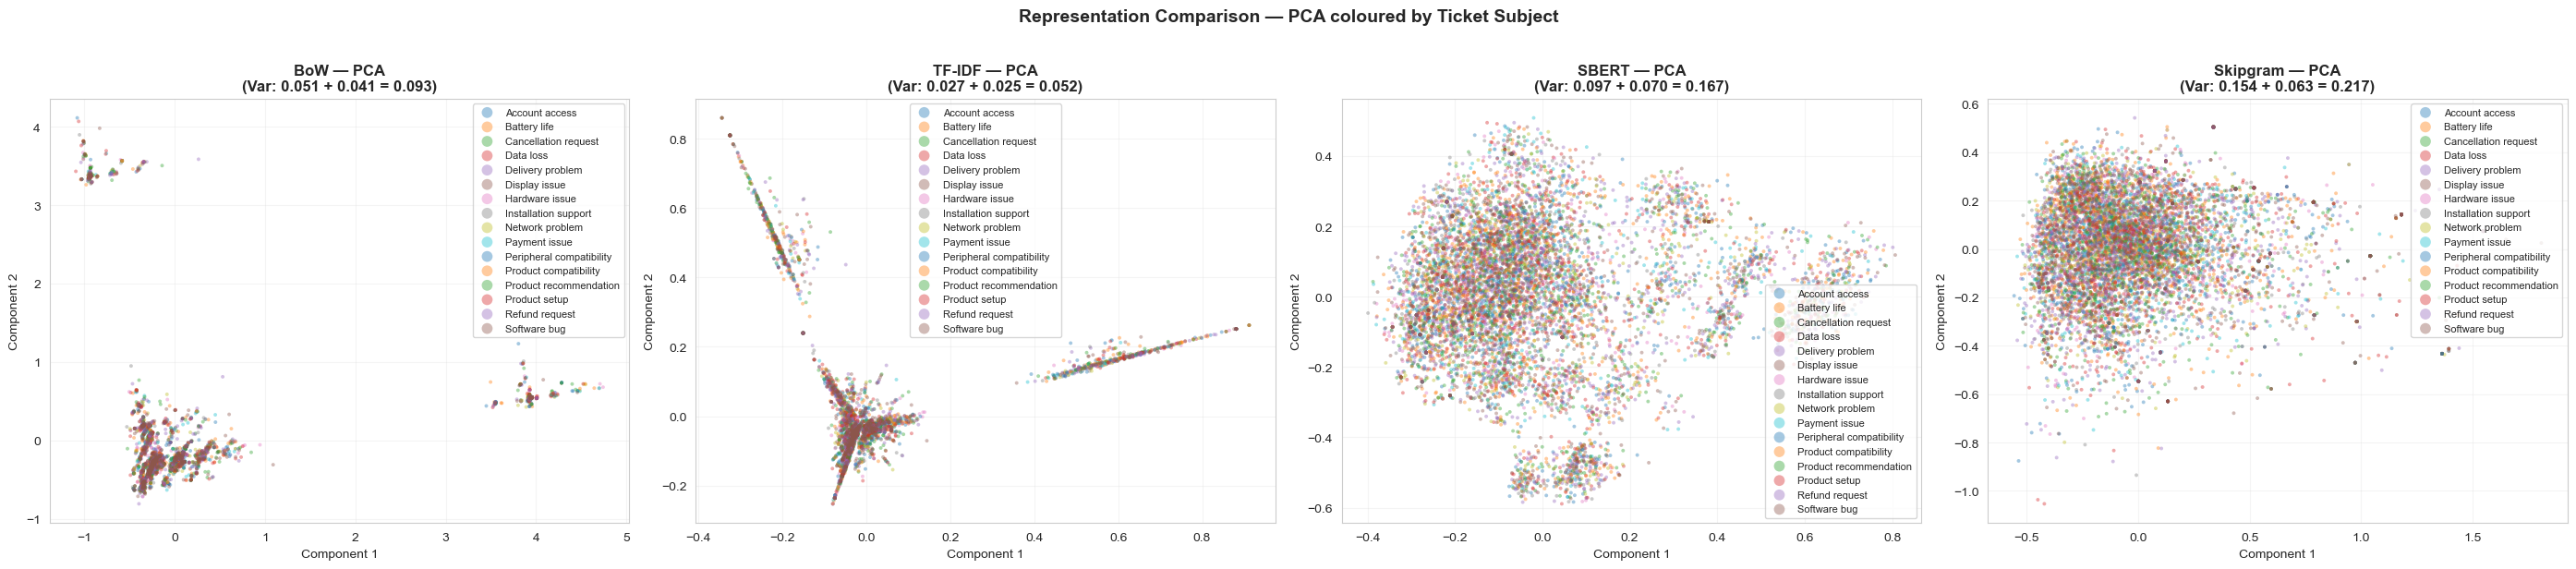

In [11]:
def compare_pca(representations, df, label_col='Ticket Type'):
    n = len(representations)
    fig, axes = plt.subplots(1, n, figsize=(7*n, 6))
    if n == 1: axes = [axes]
    labels = df[label_col].values
    unique_labels = sorted(set(labels))
    palette = sns.color_palette('tab10', len(unique_labels))
    for ax, (X, name) in zip(axes, representations):
        X_dense = X.toarray() if hasattr(X, 'toarray') else np.array(X)
        pca = PCA(n_components=2, random_state=42)
        X_2d = pca.fit_transform(X_dense)
        ev = pca.explained_variance_ratio_
        for i, label in enumerate(unique_labels):
            mask = labels == label
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[palette[i]],
                      label=label, alpha=0.4, s=8, edgecolors='none')
        ax.set_title(f'{name} — PCA\n(Var: {ev[0]:.3f} + {ev[1]:.3f} = {sum(ev):.3f})',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')
        ax.legend(fontsize=8, markerscale=3)
        ax.grid(True, alpha=0.2)
    fig.suptitle(f'Representation Comparison — PCA coloured by {label_col}',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

reps = [(X_bow, 'BoW'), (X_tfidf, 'TF-IDF'), (X_sbert, 'SBERT'), (X_skipgram, 'Skipgram')]
compare_pca(reps, df, 'Ticket Type')
compare_pca(reps, df, 'Ticket Subject')


# 4. Part 1 — Clustering Analysis (Req 1)

In [12]:
def run_clustering_sweep(X, y_type, y_subj, name, metric='cosine', k_range=range(2, 11)):
    X_dense = X.toarray() if hasattr(X, 'toarray') else np.array(X)
    results = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km_labels = km.fit_predict(X_dense)
        km_sil = silhouette_score(X_dense, km_labels, sample_size=2000, metric=metric)
        km_ari_type = adjusted_rand_score(y_type, km_labels)
        km_nmi_type = normalized_mutual_info_score(y_type, km_labels)
        km_ari_subj = adjusted_rand_score(y_subj, km_labels)
        km_nmi_subj = normalized_mutual_info_score(y_subj, km_labels)
        results.append({'Representation': name, 'Algorithm': 'KMeans', 'k': k,
            'Silhouette': km_sil, 'ARI (Type)': km_ari_type, 'NMI (Type)': km_nmi_type,
            'ARI (Subject)': km_ari_subj, 'NMI (Subject)': km_nmi_subj})
        hac = AgglomerativeClustering(n_clusters=k, linkage='ward')
        hac_labels = hac.fit_predict(X_dense)
        hac_sil = silhouette_score(X_dense, hac_labels, sample_size=2000, metric=metric)
        hac_ari_type = adjusted_rand_score(y_type, hac_labels)
        hac_nmi_type = normalized_mutual_info_score(y_type, hac_labels)
        hac_ari_subj = adjusted_rand_score(y_subj, hac_labels)
        hac_nmi_subj = normalized_mutual_info_score(y_subj, hac_labels)
        results.append({'Representation': name, 'Algorithm': 'HAC', 'k': k,
            'Silhouette': hac_sil, 'ARI (Type)': hac_ari_type, 'NMI (Type)': hac_nmi_type,
            'ARI (Subject)': hac_ari_subj, 'NMI (Subject)': hac_nmi_subj})
    return pd.DataFrame(results)

le = LabelEncoder()
y_type = le.fit_transform(df['Ticket Type'])
y_subj = le.fit_transform(df['Ticket Subject'])

print("Running clustering sweeps...")
df_tfidf = run_clustering_sweep(X_tfidf, y_type, y_subj, 'TF-IDF', metric='cosine')
df_sbert = run_clustering_sweep(X_sbert, y_type, y_subj, 'SBERT', metric='cosine')
df_bow = run_clustering_sweep(X_bow, y_type, y_subj, 'BoW', metric='cosine')
df_skip = run_clustering_sweep(X_skipgram, y_type, y_subj, 'Skipgram', metric='cosine')
all_results = pd.concat([df_tfidf, df_sbert, df_bow, df_skip], ignore_index=True)
print(f"Done. Total runs: {len(all_results)}")


Running clustering sweeps...
Done. Total runs: 72


In [13]:
summary = (all_results.groupby(['Representation', 'Algorithm'])
           .apply(lambda g: g.loc[g['Silhouette'].idxmax()])
           .reset_index(drop=True)
           [['Representation', 'Algorithm', 'k', 'Silhouette', 'ARI (Type)', 'NMI (Type)', 'ARI (Subject)', 'NMI (Subject)']]
           .sort_values('Silhouette', ascending=False))
print("=== Best Clustering Results by Representation ===")
display(summary.round(4))


=== Best Clustering Results by Representation ===


/var/folders/tf/r3_0tdhx5sq5pdqx8lk8bb200000gn/T/ipykernel_19578/3992943859.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.loc[g['Silhouette'].idxmax()])


,Representation,Algorithm,k,Silhouette,ARI (Type),NMI (Type),ARI (Subject),NMI (Subject)
2,SBERT,HAC,10,0.2546,0.0002,0.0011,0.0000,0.0031
3,SBERT,KMeans,10,0.2233,0.0001,0.0011,-0.0002,0.0030
1,BoW,KMeans,10,0.1820,-0.0001,0.0016,-0.0000,0.0040
0,BoW,HAC,10,0.1475,-0.0001,0.0015,-0.0001,0.0036
7,TF-IDF,KMeans,10,0.1395,0.0003,0.0013,0.0001,0.0037
5,Skipgram,KMeans,8,0.1035,-0.0001,0.0007,-0.0000,0.0026
6,TF-IDF,HAC,10,0.0890,0.0002,0.0015,-0.0000,0.0040
4,Skipgram,HAC,5,0.0743,-0.0001,0.0002,-0.0000,0.0015


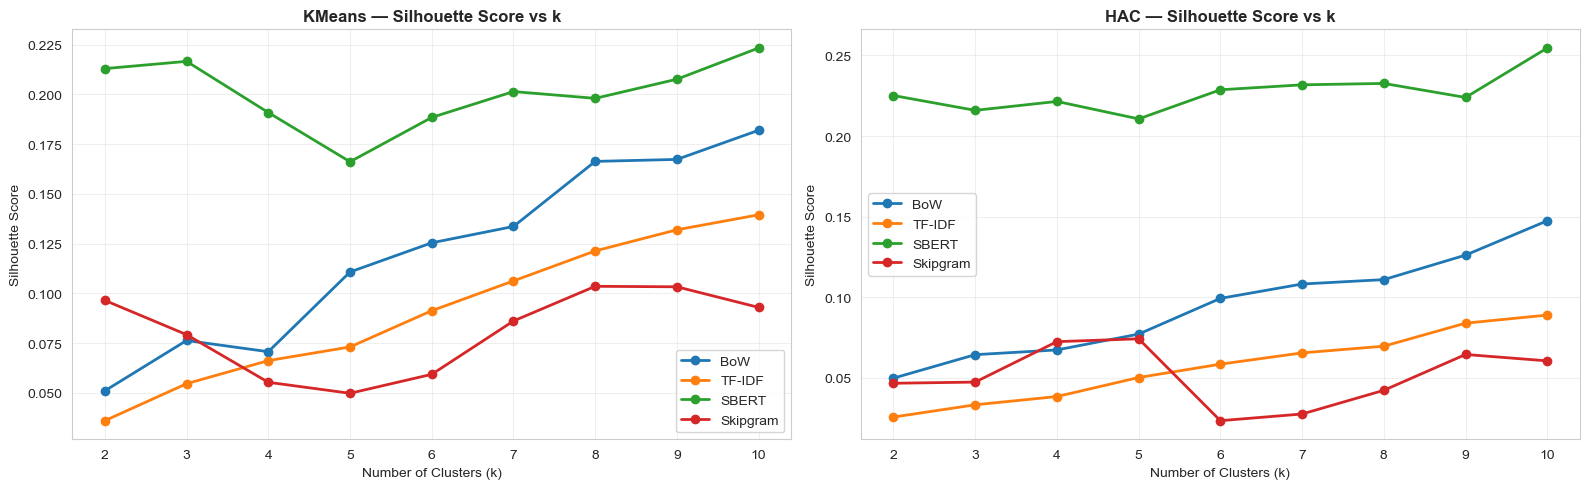

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, algo in zip(axes, ['KMeans', 'HAC']):
    subset = all_results[all_results['Algorithm'] == algo]
    for rep in ['BoW', 'TF-IDF', 'SBERT', 'Skipgram']:
        rep_data = subset[subset['Representation'] == rep]
        ax.plot(rep_data['k'], rep_data['Silhouette'], marker='o', label=rep, linewidth=2)
    ax.set_title(f'{algo} — Silhouette Score vs k', fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Clusters (k)')
    ax.set_ylabel('Silhouette Score')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(2, 11))
plt.tight_layout()
plt.show()


## 4.1 Cluster Interpretability

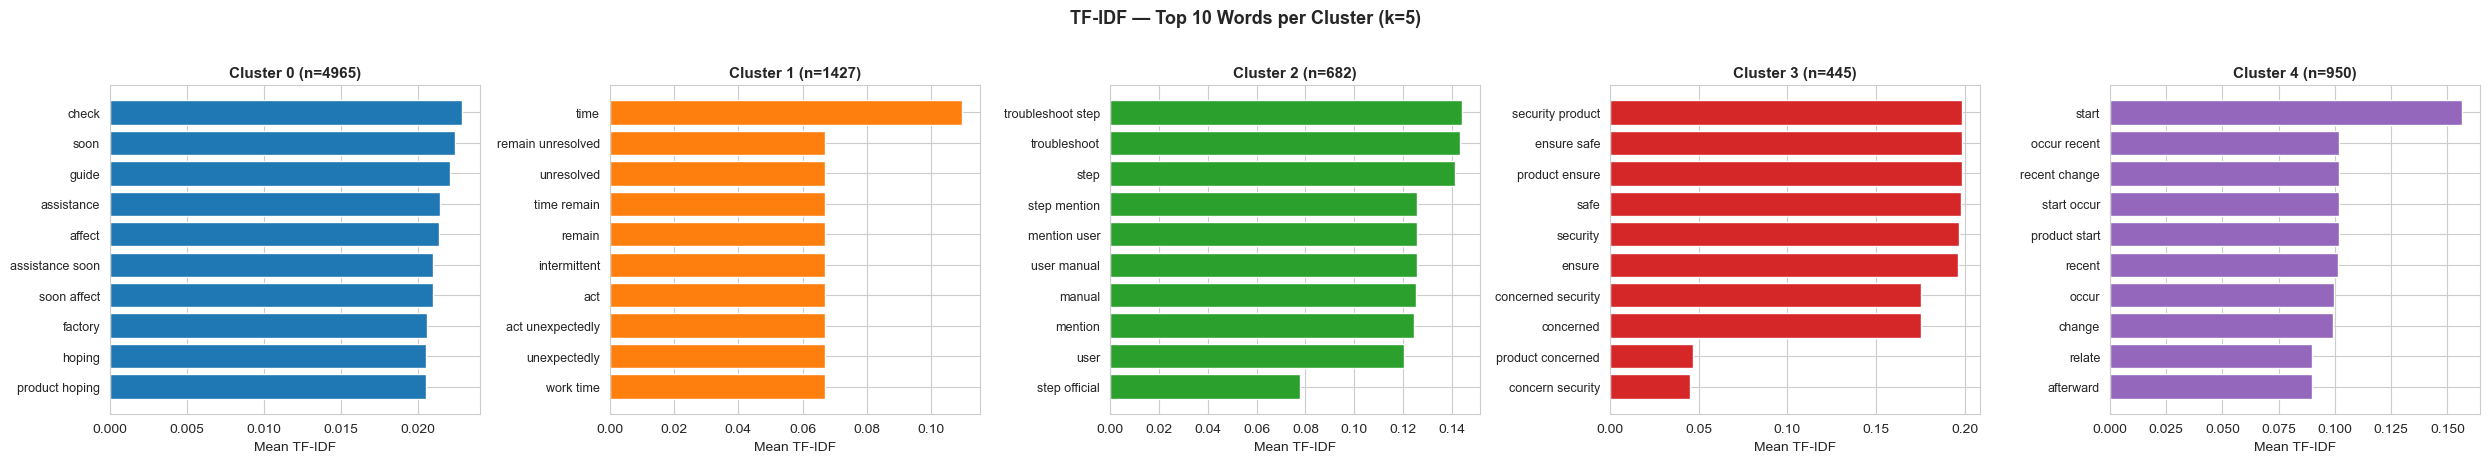

In [15]:
km_tfidf_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
km_tfidf_labels = km_tfidf_5.fit_predict(X_tfidf.toarray())
km_sbert_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
km_sbert_labels = km_sbert_5.fit_predict(X_sbert)

def plot_cluster_top_words(X, cluster_labels, vectorizer, n_top=10, title_prefix="TF-IDF"):
    feature_names = vectorizer.get_feature_names_out()
    X_dense = X.toarray() if hasattr(X, 'toarray') else X
    n_clusters = len(set(cluster_labels))
    fig, axes = plt.subplots(1, n_clusters, figsize=(5*n_clusters, 4.5))
    if n_clusters == 1: axes = [axes]
    for c in sorted(set(cluster_labels)):
        mask = cluster_labels == c
        cluster_mean = X_dense[mask].mean(axis=0)
        if hasattr(cluster_mean, 'A1'): cluster_mean = cluster_mean.A1
        top_idx = cluster_mean.argsort()[-n_top:][::-1]
        ax = axes[c]
        ax.barh(range(n_top), [cluster_mean[i] for i in top_idx],
                color=sns.color_palette('tab10')[c])
        ax.set_yticks(range(n_top))
        ax.set_yticklabels([feature_names[i] for i in top_idx], fontsize=9)
        ax.invert_yaxis()
        ax.set_title(f'Cluster {c} (n={mask.sum()})', fontsize=11, fontweight='bold')
        ax.set_xlabel('Mean TF-IDF')
    fig.suptitle(f'{title_prefix} — Top {n_top} Words per Cluster (k={n_clusters})',
                fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_cluster_top_words(X_tfidf, km_tfidf_labels, tfidf_vectorizer)


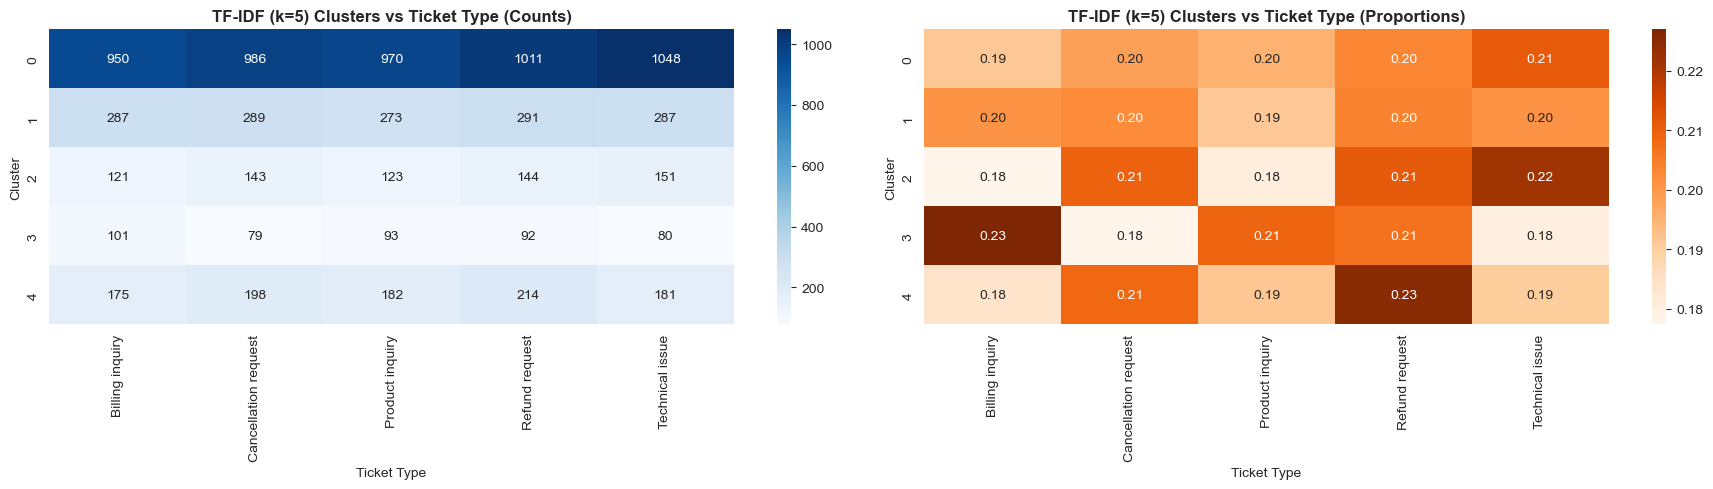

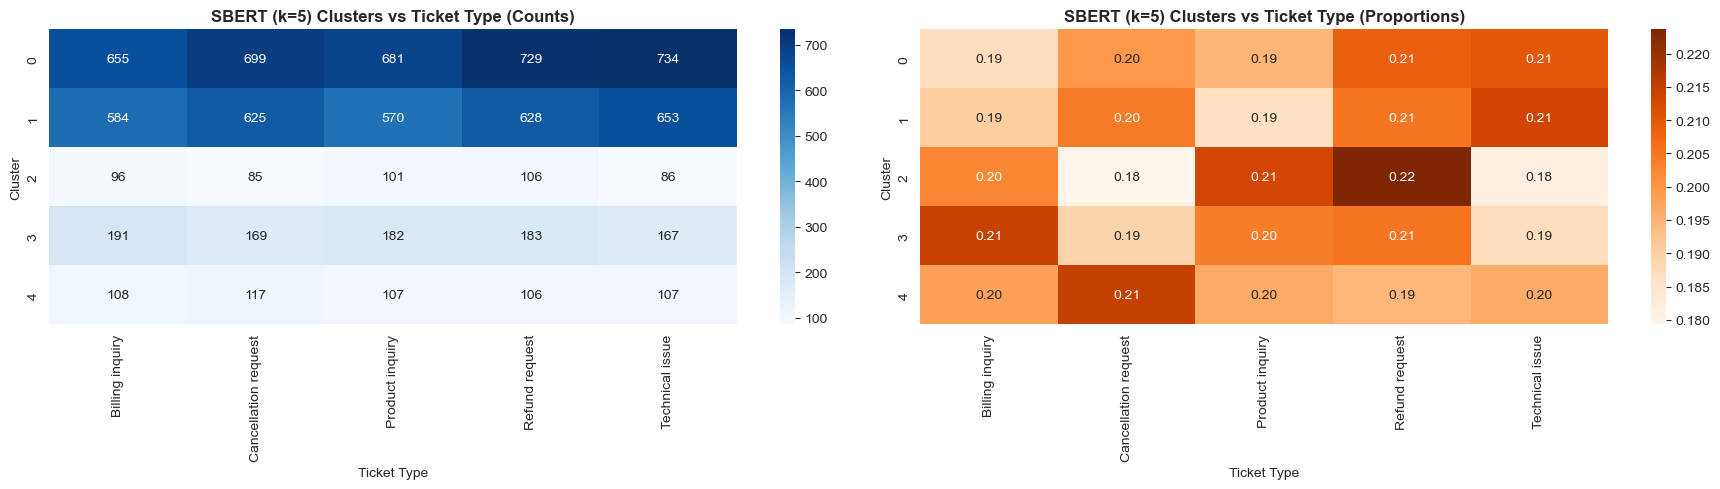

In [16]:
def plot_cluster_heatmaps(cluster_labels, df, title_prefix="TF-IDF"):
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    ct = pd.crosstab(cluster_labels, df['Ticket Type'])
    ct_norm = ct.div(ct.sum(axis=1), axis=0)
    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'{title_prefix} Clusters vs Ticket Type (Counts)', fontweight='bold')
    axes[0].set_ylabel('Cluster')
    sns.heatmap(ct_norm, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1])
    axes[1].set_title(f'{title_prefix} Clusters vs Ticket Type (Proportions)', fontweight='bold')
    axes[1].set_ylabel('Cluster')
    plt.tight_layout()
    plt.show()

plot_cluster_heatmaps(km_tfidf_labels, df, "TF-IDF (k=5)")
plot_cluster_heatmaps(km_sbert_labels, df, "SBERT (k=5)")


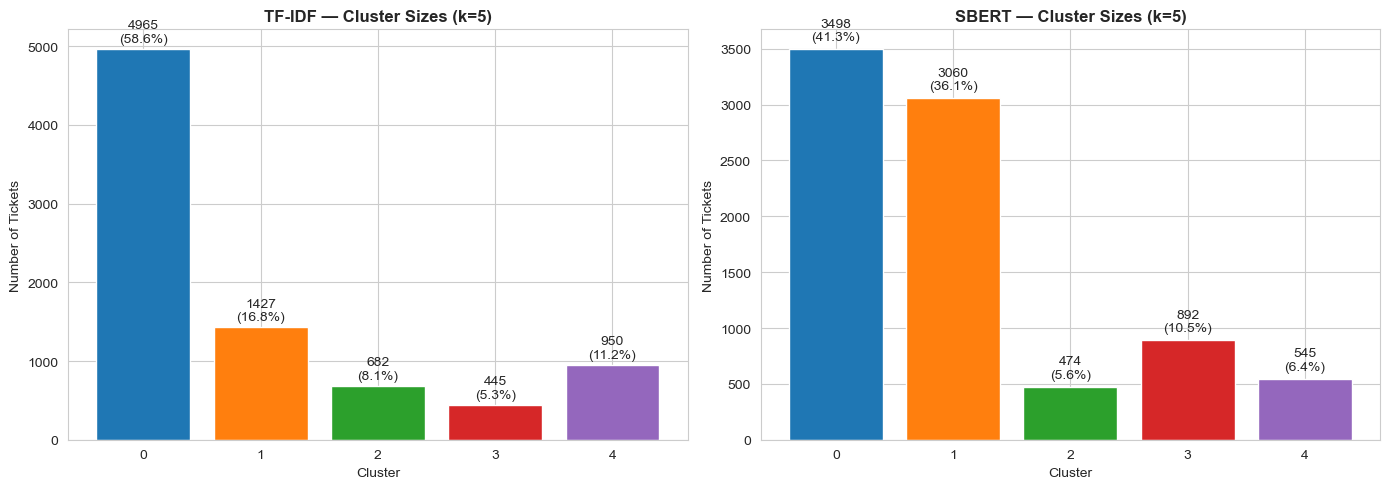

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (labels, name) in zip(axes, [(km_tfidf_labels, "TF-IDF"), (km_sbert_labels, "SBERT")]):
    unique, counts = np.unique(labels, return_counts=True)
    colors = sns.color_palette('tab10', len(unique))
    bars = ax.bar(unique, counts, color=colors)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{count}\n({count/len(labels)*100:.1f}%)',
                ha='center', va='bottom', fontsize=10)
    ax.set_title(f'{name} — Cluster Sizes (k=5)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Number of Tickets')
plt.tight_layout()
plt.show()


## 4.2 Cluster Stability Across k

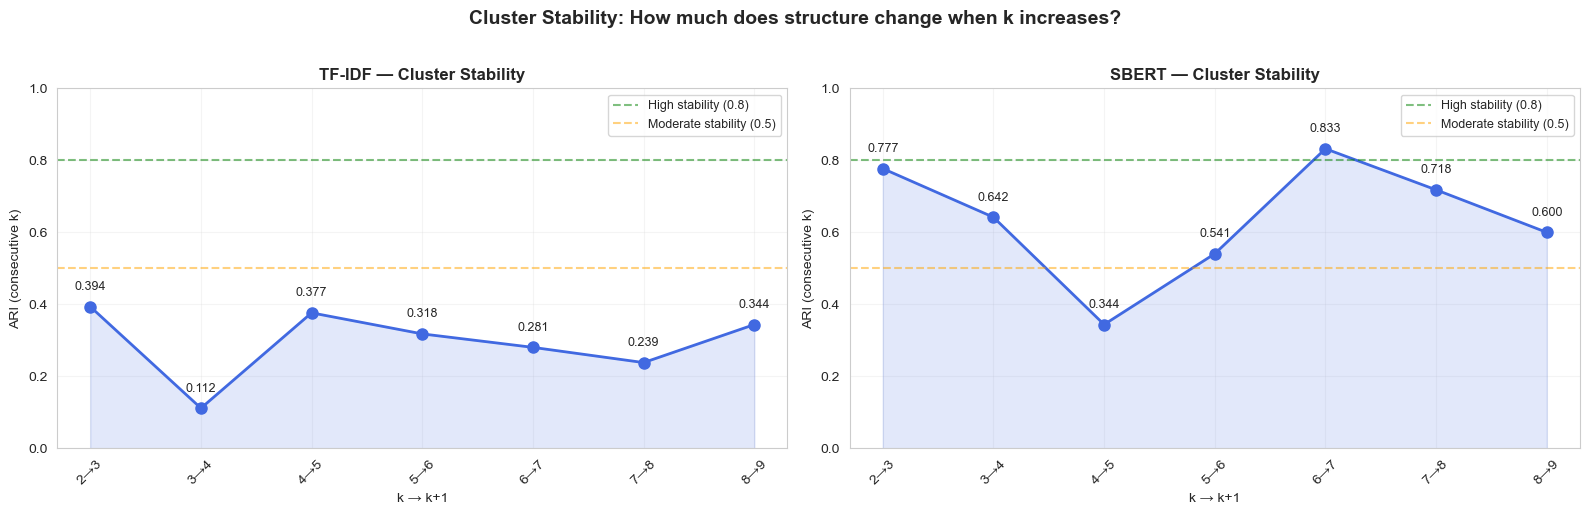

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (name, X_rep) in zip(axes, [("TF-IDF", X_tfidf), ("SBERT", X_sbert)]):
    X_dense = X_rep.toarray() if hasattr(X_rep, 'toarray') else np.array(X_rep)
    k_labels = {}
    for k in range(2, 10):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        k_labels[k] = km.fit_predict(X_dense)
    k_pairs = list(range(2, 9))
    ari_scores = [adjusted_rand_score(k_labels[k], k_labels[k+1]) for k in k_pairs]
    ax.plot(k_pairs, ari_scores, marker='o', linewidth=2, markersize=8, color='royalblue')
    ax.fill_between(k_pairs, ari_scores, alpha=0.15, color='royalblue')
    for k, ari in zip(k_pairs, ari_scores):
        ax.annotate(f'{ari:.3f}', (k, ari), textcoords="offset points",
                    xytext=(0, 12), ha='center', fontsize=9)
    ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='High stability (0.8)')
    ax.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='Moderate stability (0.5)')
    ax.set_title(f'{name} — Cluster Stability', fontsize=12, fontweight='bold')
    ax.set_xlabel('k → k+1')
    ax.set_ylabel('ARI (consecutive k)')
    ax.set_xticks(k_pairs)
    ax.set_xticklabels([f'{k}→{k+1}' for k in k_pairs], rotation=45)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.2)
plt.suptitle('Cluster Stability: How much does structure change when k increases?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Hypotheses

### Axis 1: Topic Discovery — LDA vs BERTopic

**H1a (LDA):** LDA, which decomposes a bag-of-words matrix into latent topics via word co-occurrence statistics, will produce *more interpretable and evenly distributed* topics on this corpus. Because the dataset is generated from templates with shared vocabulary across ticket types, co-occurrence patterns (e.g., "error" + "screen" + "crash") should form coherent word clusters that map to recognisable issue categories.

**H1b (BERTopic):** BERTopic, which clusters SBERT sentence embeddings and then extracts topic labels via c-TF-IDF, will struggle with this corpus. Sentence embeddings capture semantic similarity, and because the templated tickets share phrasing and structure across types, many documents will be mapped to a single dense region in embedding space — resulting in one dominant mega-topic and a high outlier rate.

### Axis 2: Sentiment Analysis — VADER vs TextBlob

**H2a (VADER):** VADER, a lexicon built for social-media text with rules for punctuation, capitalisation and intensifiers, will produce a *wider range* of sentiment scores because customer complaints contain informal, emotionally charged language (e.g., "frustrated", "terrible") that VADER's lexicon is tuned to amplify.

**H2b (TextBlob):** TextBlob's pattern-based polarity, trained on product reviews, will produce a *narrower* and more neutral-leaning distribution, since it lacks specialised rules for complaint language and treats most template filler as neutral.

**H2c (Both):** Given that the dataset is synthetically generated, neither tool should reveal significant sentiment differences *between* ticket types or subjects, since the generator does not condition emotional tone on category.

# 5. Part 2 — Design Axes

## Axis 1: Topic Discovery — LDA vs BERTopic

In [19]:
from sklearn.model_selection import train_test_split

# --- Train/Test Split ---
train_idx, test_idx = train_test_split(
    range(len(df)), test_size=0.2, random_state=42
)
train_text = [clean_text.iloc[i] for i in train_idx]
test_text = [clean_text.iloc[i] for i in test_idx]

print(f"Train size: {len(train_text)}, Test size: {len(test_text)}")

# --- LDA Topic Modelling (fit on train) ---
print("\n=== LDA Topic Modelling ===")
lda_vectorizer = TfidfVectorizer(max_features=3000, min_df=3, max_df=0.85)
X_lda_train = lda_vectorizer.fit_transform(train_text)
X_lda_test = lda_vectorizer.transform(test_text)

print(f"LDA TF-IDF train shape: {X_lda_train.shape}")
print(f"LDA TF-IDF test shape:  {X_lda_test.shape}")

for n_topics in [5, 8, 10]:
    lda = LatentDirichletAllocation(
        n_components=n_topics, random_state=42, max_iter=20, learning_method='online'
    )
    lda.fit(X_lda_train)
    feature_names_lda = lda_vectorizer.get_feature_names_out()
    train_perp = lda.perplexity(X_lda_train)
    test_perp = lda.perplexity(X_lda_test)
    print(f"\n--- LDA with {n_topics} topics (Train perplexity: {train_perp:.2f}, Test perplexity: {test_perp:.2f}) ---")
    for topic_idx, topic in enumerate(lda.components_):
        top_words = [feature_names_lda[i] for i in topic.argsort()[-8:][::-1]]
        print(f"  Topic {topic_idx}: {', '.join(top_words)}")


Train size: 6775, Test size: 1694

=== LDA Topic Modelling ===
LDA TF-IDF train shape: (6775, 1307)
LDA TF-IDF test shape:  (1694, 1307)

--- LDA with 5 topics (Train perplexity: 872.49, Test perplexity: 1927.78) ---
  Topic 0: user, remain, unresolved, mention, contact, manual, time, delete
  Topic 1: different, ensure, security, safe, access, concerned, configuration, model
  Topic 2: network, change, connect, recent, occur, password, start, require
  Topic 3: update, notice, error, soon, assistance, affect, message, app
  Topic 4: factory, hoping, work, intermittent, act, unexpectedly, perform, guide

--- LDA with 8 topics (Train perplexity: 1088.34, Test perplexity: 2816.56) ---
  Topic 0: happen, remain, unresolved, contact, firmware, relate, afterward, recently
  Topic 1: ensure, security, safe, access, concerned, log, display, login
  Topic 2: setting, configuration, different, configure, check, correctly, sure, productid
  Topic 3: notice, screen, error, soon, user, assistance,

Train perplexity: 872.49
Test perplexity:  1927.78


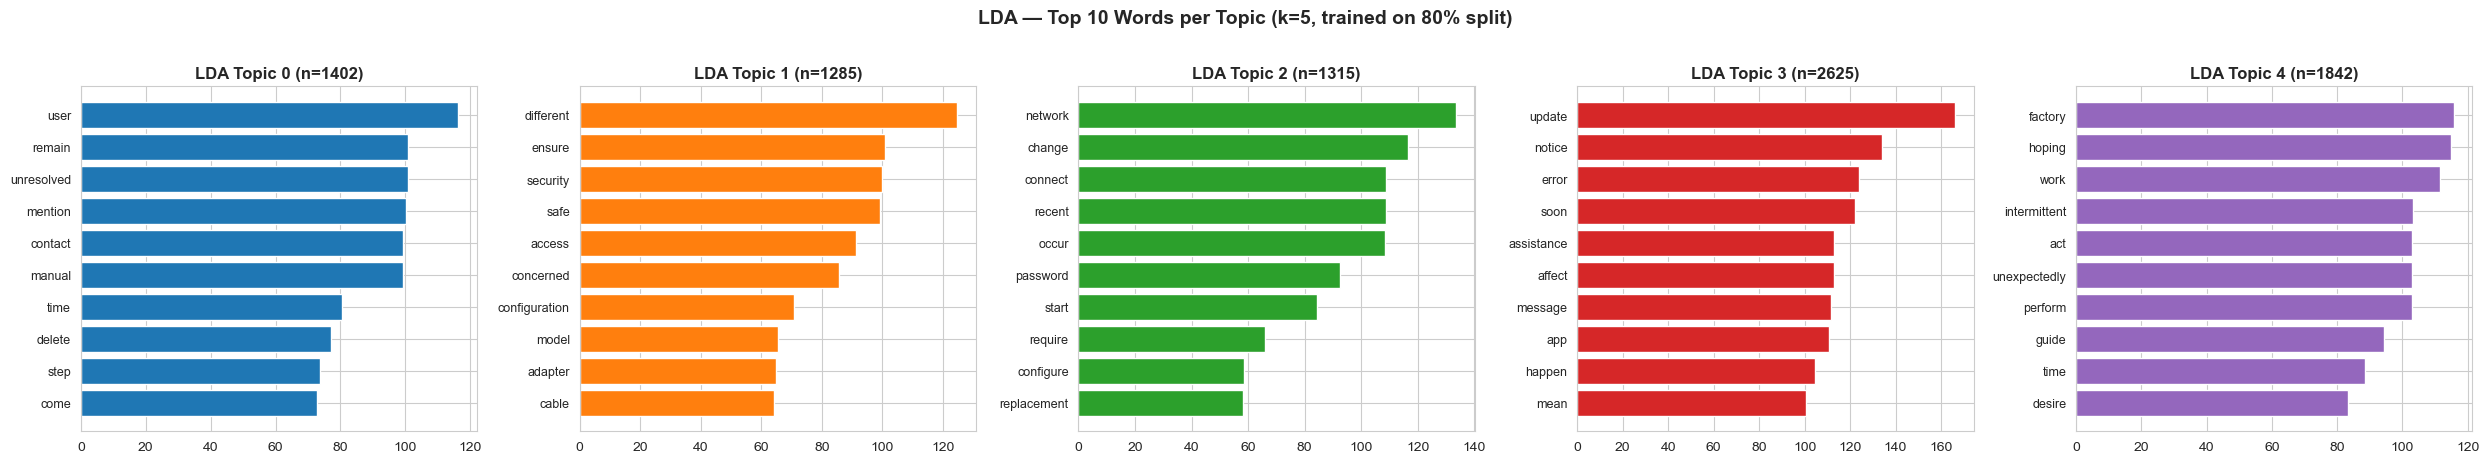


=== LDA Topics vs Ticket Type (TEST SET) ===
col_0  Billing inquiry  Cancellation request  Product inquiry  Refund request  \
row_0                                                                           
0                 0.24                  0.21             0.15            0.20   
1                 0.18                  0.22             0.21            0.20   
2                 0.20                  0.21             0.19            0.21   
3                 0.22                  0.19             0.20            0.20   
4                 0.21                  0.16             0.18            0.21   

col_0  Technical issue  
row_0                   
0                 0.21  
1                 0.19  
2                 0.19  
3                 0.19  
4                 0.24  

=== LDA Topics vs Ticket Type (FULL CORPUS) ===
Ticket Type  Billing inquiry  Cancellation request  Product inquiry  \
row_0                                                                 
0                   

In [20]:
# --- LDA with k=5 (final model, fit on train) ---
lda_5 = LatentDirichletAllocation(
    n_components=5, random_state=42, max_iter=20, learning_method='online'
)
lda_train_topics = lda_5.fit_transform(X_lda_train)
lda_test_topics = lda_5.transform(X_lda_test)

lda_train_labels = lda_train_topics.argmax(axis=1)
lda_test_labels = lda_test_topics.argmax(axis=1)

# Full-corpus labels for downstream comparisons (train + test)
lda_labels = np.empty(len(df), dtype=int)
lda_labels[train_idx] = lda_train_labels
lda_labels[test_idx] = lda_test_labels

print(f"Train perplexity: {lda_5.perplexity(X_lda_train):.2f}")
print(f"Test perplexity:  {lda_5.perplexity(X_lda_test):.2f}")

feature_names_lda = lda_vectorizer.get_feature_names_out()

# --- Visualize LDA topics (from trained model) ---
fig, axes = plt.subplots(1, 5, figsize=(25, 4.5))
for topic_idx in range(5):
    top_idx = lda_5.components_[topic_idx].argsort()[-10:][::-1]
    top_words = [feature_names_lda[i] for i in top_idx]
    top_weights = [lda_5.components_[topic_idx][i] for i in top_idx]
    axes[topic_idx].barh(range(10), top_weights, color=sns.color_palette('tab10')[topic_idx])
    axes[topic_idx].set_yticks(range(10))
    axes[topic_idx].set_yticklabels(top_words, fontsize=9)
    axes[topic_idx].invert_yaxis()
    n_docs = (lda_labels == topic_idx).sum()
    axes[topic_idx].set_title(f'LDA Topic {topic_idx} (n={n_docs})', fontweight='bold')
fig.suptitle('LDA — Top 10 Words per Topic (k=5, trained on 80% split)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Cross-tab on TEST set ---
print("\n=== LDA Topics vs Ticket Type (TEST SET) ===")
df_test = df.iloc[test_idx]
ct_lda_test = pd.crosstab(lda_test_labels, df_test['Ticket Type'].values)
ct_lda_test_norm = ct_lda_test.div(ct_lda_test.sum(axis=1), axis=0)
print(ct_lda_test_norm.round(2))

print("\n=== LDA Topics vs Ticket Type (FULL CORPUS) ===")
ct_lda = pd.crosstab(lda_labels, df['Ticket Type'])
ct_lda_norm = ct_lda.div(ct_lda.sum(axis=1), axis=0)
print(ct_lda_norm.round(2))


In [21]:
from bertopic import BERTopic

print("=== BERTopic Topic Modelling (Train/Test Split) ===")

# Prepare cleaned text for SBERT
sbert_text_list = (df['Ticket Description']
                   .apply(to_lower)
                   .apply(expand_contractions_fn)
                   .apply(replace_product_placeholder)
                   .apply(remove_noise)
                   .tolist())

sbert_train = [sbert_text_list[i] for i in train_idx]
sbert_test = [sbert_text_list[i] for i in test_idx]

# Fit on train
topic_model = BERTopic(nr_topics=10, min_topic_size=50, verbose=True)
topics_train, probs_train = topic_model.fit_transform(sbert_train)

# Transform test
topics_test, probs_test = topic_model.transform(sbert_test)

# Full-corpus topic labels
topics_all = np.empty(len(df), dtype=int)
topics_all[train_idx] = topics_train
topics_all[test_idx] = topics_test

n_train_topics = len(set(topics_train)) - (1 if -1 in topics_train else 0)
n_test_outliers = (np.array(topics_test) == -1).sum()
print(f"\nTopics found (train): {n_train_topics}")
print(f"Train outliers: {(np.array(topics_train) == -1).sum()}")
print(f"Test outliers:  {n_test_outliers} / {len(topics_test)}")

topic_info = topic_model.get_topic_info()
print("\n=== BERTopic Topics ===")
for _, row in topic_info.head(12).iterrows():
    if row['Topic'] == -1: continue
    topic_words = topic_model.get_topic(row['Topic'])
    words = ', '.join([w for w, _ in topic_words[:8]])
    print(f"  Topic {row['Topic']} (n={row['Count']}): {words}")


2026-04-10 14:11:46,878 - BERTopic - Embedding - Transforming documents to embeddings.


=== BERTopic Topic Modelling (Train/Test Split) ===


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/212 [00:00<?, ?it/s]

2026-04-10 14:11:55,179 - BERTopic - Embedding - Completed ✓
2026-04-10 14:11:55,179 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-10 14:12:01,864 - BERTopic - Dimensionality - Completed ✓
2026-04-10 14:12:01,865 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-10 14:12:02,008 - BERTopic - Cluster - Completed ✓
2026-04-10 14:12:02,009 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-10 14:12:02,090 - BERTopic - Representation - Completed ✓
2026-04-10 14:12:02,090 - BERTopic - Topic reduction - Reducing number of topics
2026-04-10 14:12:02,094 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-10 14:12:02,160 - BERTopic - Representation - Completed ✓
2026-04-10 14:12:02,160 - BERTopic - Topic reduction - Reduced number of topics from 39 to 10


Batches:   0%|          | 0/53 [00:00<?, ?it/s]

2026-04-10 14:12:03,785 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-04-10 14:12:07,291 - BERTopic - Dimensionality - Completed ✓
2026-04-10 14:12:07,291 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-04-10 14:12:07,315 - BERTopic - Cluster - Completed ✓



Topics found (train): 9
Train outliers: 709
Test outliers:  163 / 1694

=== BERTopic Topics ===
  Topic 0 (n=3659): the, product, issue, please, with, an, am, assist
  Topic 1 (n=439): software, bug, in, the, it, to, there, can
  Topic 2 (n=410): to, network, troubleshoot, networks, this, connecting, it, my
  Topic 3 (n=380): data, files, deleted, have, them, to, way, my
  Topic 4 (n=362): account, my, password, it, how, to, can, is
  Topic 5 (n=269): the, desired, through, find, guide, action, perform, option
  Topic 6 (n=265): concerned, safe, ensure, security, like, about, would, my
  Topic 7 (n=145): charger, charging, came, original, properly, using, with, am
  Topic 8 (n=137): flickering, screen, hardware, to, seems, should, do, use


=== BERTopic Topics vs Ticket Type (TEST SET) ===
col_0  Billing inquiry  Cancellation request  Product inquiry  Refund request  \
row_0                                                                           
0                 0.21                  0.19             0.19            0.20   
1                 0.29                  0.20             0.18            0.21   
2                 0.25                  0.21             0.15            0.24   
3                 0.22                  0.21             0.15            0.22   
4                 0.19                  0.16             0.20            0.21   
5                 0.18                  0.18             0.15            0.20   
6                 0.26                  0.20             0.25            0.15   
7                 0.21                  0.23             0.14            0.16   
8                 0.25                  0.16             0.19            0.19   

col_0  Technical issue  
row_0                   
0       

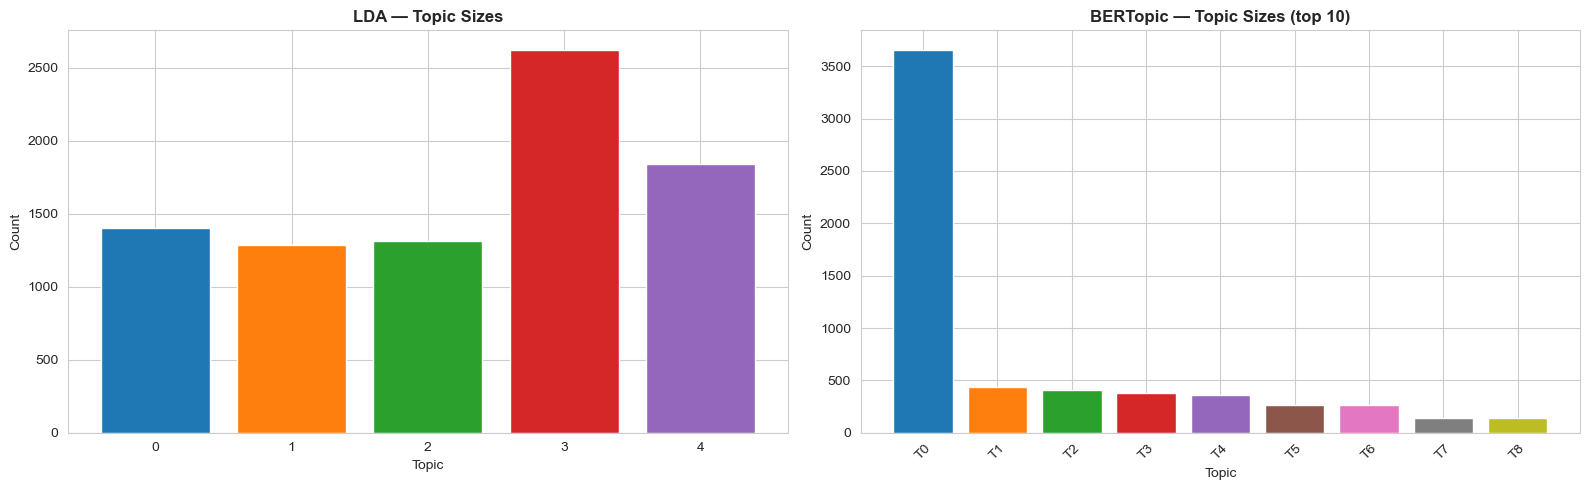

In [22]:
bt_labels = topics_all.copy()
valid_mask = bt_labels != -1

# --- Cross-tab on TEST set ---
bt_test_labels = np.array(topics_test)
valid_test = bt_test_labels != -1
print("=== BERTopic Topics vs Ticket Type (TEST SET) ===")
ct_bt_test = pd.crosstab(bt_test_labels[valid_test],
                          df.iloc[test_idx]['Ticket Type'].values[valid_test])
ct_bt_test_norm = ct_bt_test.div(ct_bt_test.sum(axis=1), axis=0)
print(ct_bt_test_norm.round(2))

# --- Full corpus cross-tab ---
print("\n=== BERTopic Topics vs Ticket Type (FULL CORPUS) ===")
ct_bt = pd.crosstab(bt_labels[valid_mask], df['Ticket Type'].values[valid_mask])
ct_bt_norm = ct_bt.div(ct_bt.sum(axis=1), axis=0)
print(ct_bt_norm.round(2))

# --- Topic size comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
lda_unique, lda_counts = np.unique(lda_labels, return_counts=True)
axes[0].bar(lda_unique, lda_counts, color=sns.color_palette('tab10', len(lda_unique)))
axes[0].set_title('LDA — Topic Sizes', fontweight='bold')
axes[0].set_xlabel('Topic')
axes[0].set_ylabel('Count')

bt_info = topic_model.get_topic_info()
bt_top = bt_info[bt_info['Topic'] != -1].head(10)
axes[1].bar(range(len(bt_top)), bt_top['Count'].values,
            color=sns.color_palette('tab10', len(bt_top)))
axes[1].set_xticks(range(len(bt_top)))
axes[1].set_xticklabels([f"T{t}" for t in bt_top['Topic'].values], rotation=45)
axes[1].set_title('BERTopic — Topic Sizes (top 10)', fontweight='bold')
axes[1].set_xlabel('Topic')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()


## Axis 2: Sentiment Analysis — VADER vs TextBlob

In [23]:
vader = SentimentIntensityAnalyzer()
df['vader_compound'] = df['Ticket Description'].apply(lambda x: vader.polarity_scores(x)['compound'])
df['vader_label'] = df['vader_compound'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral'))
df['tb_polarity'] = df['Ticket Description'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['tb_subjectivity'] = df['Ticket Description'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
df['tb_label'] = df['tb_polarity'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral'))

print("=== Sentiment Distribution ===")
print("\nVADER:")
print(df['vader_label'].value_counts())
print("\nTextBlob:")
print(df['tb_label'].value_counts())


=== Sentiment Distribution ===

VADER:
vader_label
Positive    6000
Negative    2109
Neutral      360
Name: count, dtype: int64

TextBlob:
tb_label
Positive    3766
Neutral     2794
Negative    1909
Name: count, dtype: int64


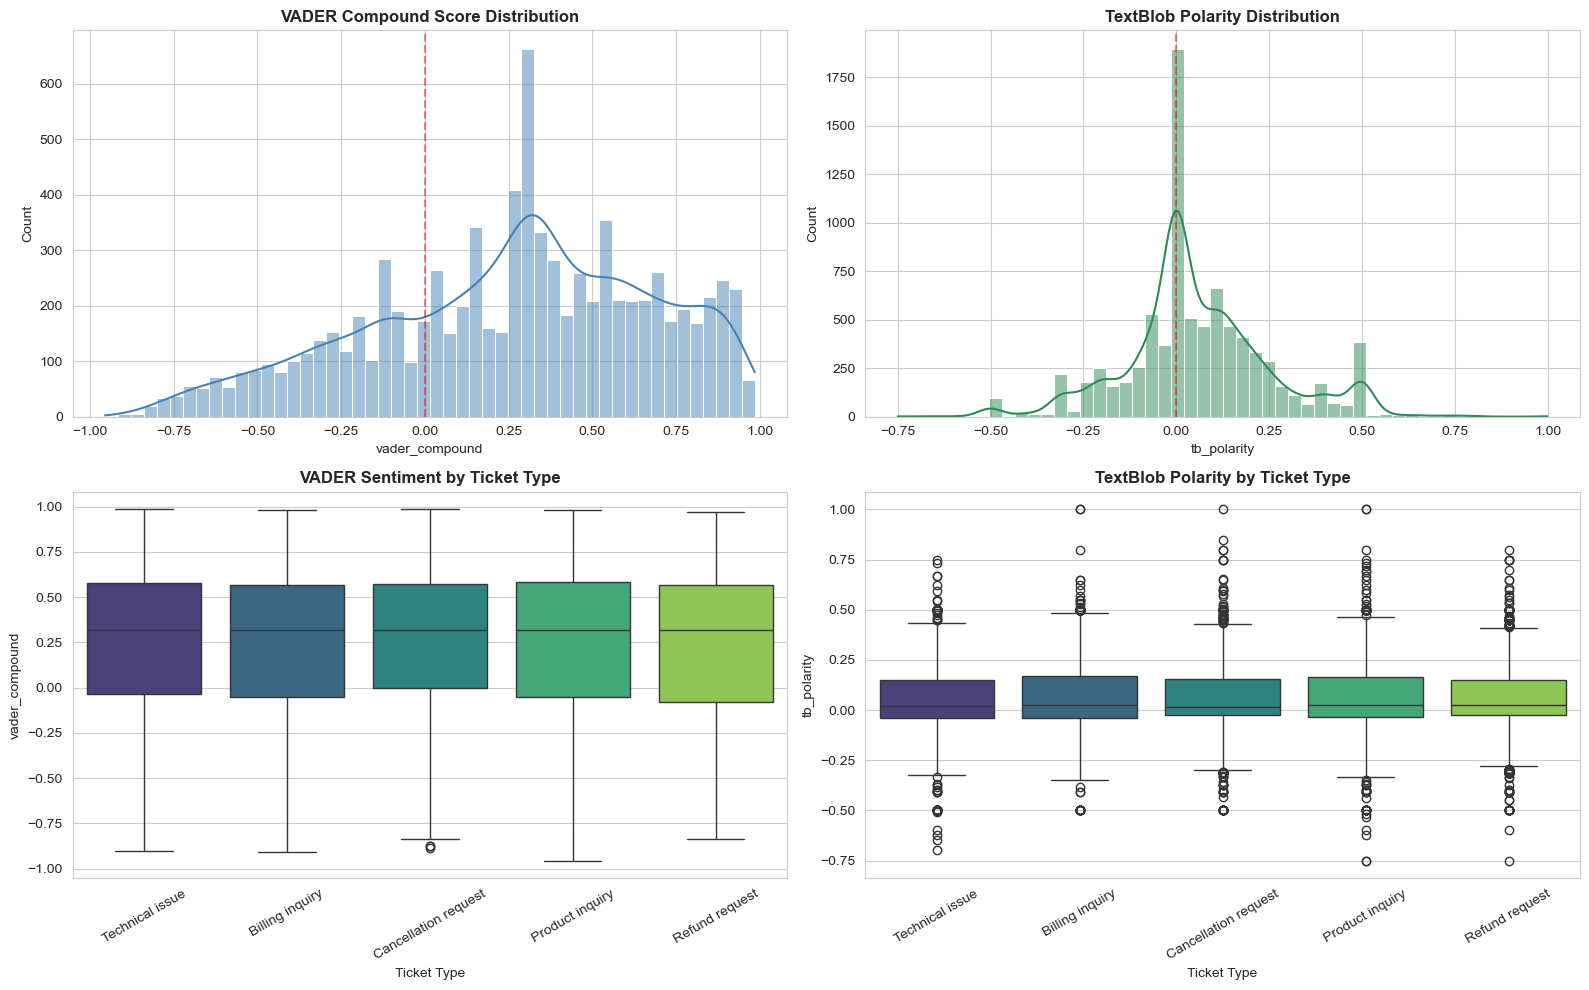

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.histplot(df['vader_compound'], bins=50, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('VADER Compound Score Distribution', fontweight='bold')
axes[0,0].axvline(0, color='red', linestyle='--', alpha=0.5)
sns.histplot(df['tb_polarity'], bins=50, kde=True, ax=axes[0,1], color='seagreen')
axes[0,1].set_title('TextBlob Polarity Distribution', fontweight='bold')
axes[0,1].axvline(0, color='red', linestyle='--', alpha=0.5)
sns.boxplot(data=df, x='Ticket Type', y='vader_compound', ax=axes[1,0], palette='viridis')
axes[1,0].set_title('VADER Sentiment by Ticket Type', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=30)
sns.boxplot(data=df, x='Ticket Type', y='tb_polarity', ax=axes[1,1], palette='viridis')
axes[1,1].set_title('TextBlob Polarity by Ticket Type', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


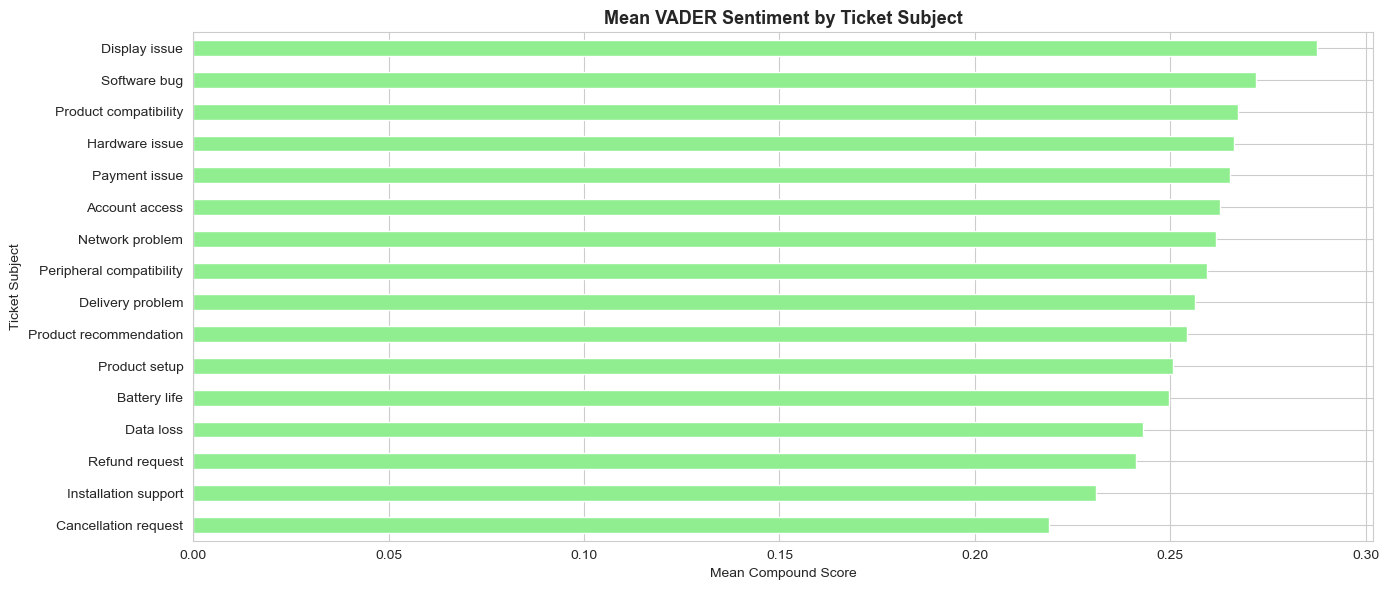

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))
subject_sentiment = df.groupby('Ticket Subject')['vader_compound'].mean().sort_values()
subject_sentiment.plot(kind='barh', ax=ax, color=[
    'salmon' if v < -0.05 else ('lightgreen' if v > 0.05 else 'lightgray')
    for v in subject_sentiment.values])
ax.set_title('Mean VADER Sentiment by Ticket Subject', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Compound Score')
ax.axvline(0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()


=== Sentiment by LDA Topic ===
           Mean Sentiment  Std Sentiment  Count
lda_topic                                      
0                   0.346          0.327   1402
1                   0.259          0.479   1285
2                   0.108          0.452   1315
3                   0.282          0.399   2625
4                   0.253          0.429   1842


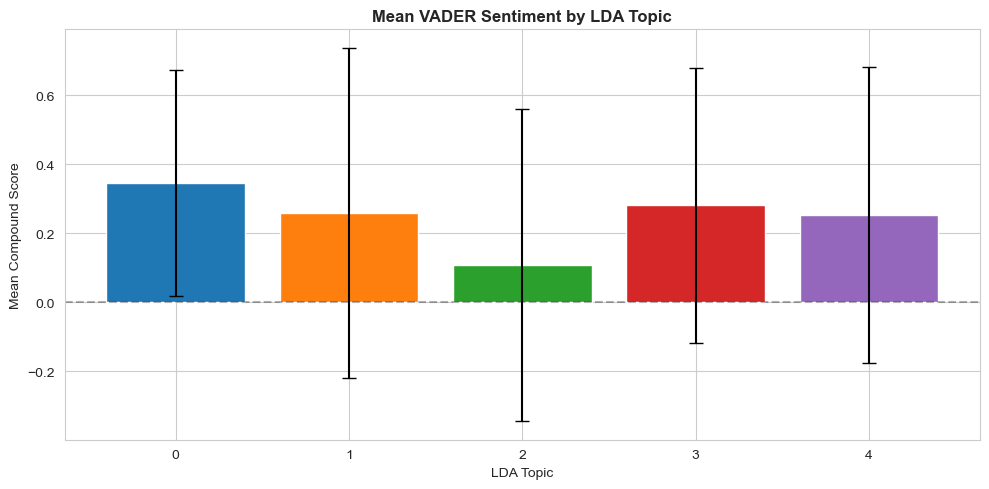

In [26]:
df['lda_topic'] = lda_labels
fig, ax = plt.subplots(figsize=(10, 5))
topic_sentiment = df.groupby('lda_topic')['vader_compound'].agg(['mean', 'std', 'count'])
topic_sentiment.columns = ['Mean Sentiment', 'Std Sentiment', 'Count']
print("=== Sentiment by LDA Topic ===")
print(topic_sentiment.round(3))
ax.bar(topic_sentiment.index, topic_sentiment['Mean Sentiment'],
       yerr=topic_sentiment['Std Sentiment'], capsize=5,
       color=sns.color_palette('tab10', len(topic_sentiment)))
ax.set_title('Mean VADER Sentiment by LDA Topic', fontweight='bold')
ax.set_xlabel('LDA Topic')
ax.set_ylabel('Mean Compound Score')
ax.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


# 6. Evaluation

This section addresses all three evaluation requirements:
- **4a.** Consistency and robustness of findings across methods
- **4b.** Coherence and interpretability of issue categories
- **4c.** Alignment with intuitive or expected patterns and with the initial clustering analysis

## 6.1 LDA Model Selection: Coherence & Perplexity Sweep (k=2–15)

=== LDA Sweep: k = 2..15 ===
  k= 2  C_v=0.3251  train_perp=642.3  test_perp=1006.5
  k= 3  C_v=0.3556  train_perp=721.5  test_perp=1312.7
  k= 4  C_v=0.3522  train_perp=791.3  test_perp=1619.1
  k= 5  C_v=0.2944  train_perp=872.5  test_perp=1927.8
  k= 6  C_v=0.4134  train_perp=941.0  test_perp=2173.8
  k= 7  C_v=0.3104  train_perp=990.9  test_perp=2504.4
  k= 8  C_v=0.4056  train_perp=1088.3  test_perp=2816.6
  k= 9  C_v=0.4292  train_perp=1107.3  test_perp=3000.2
  k=10  C_v=0.4025  train_perp=1168.1  test_perp=3395.7
  k=11  C_v=0.3959  train_perp=1246.4  test_perp=3548.3
  k=12  C_v=0.4031  train_perp=1334.7  test_perp=4099.3
  k=13  C_v=0.4614  train_perp=1342.0  test_perp=4220.0
  k=14  C_v=0.4478  train_perp=1368.9  test_perp=4369.7
  k=15  C_v=0.5082  train_perp=1416.2  test_perp=4649.7


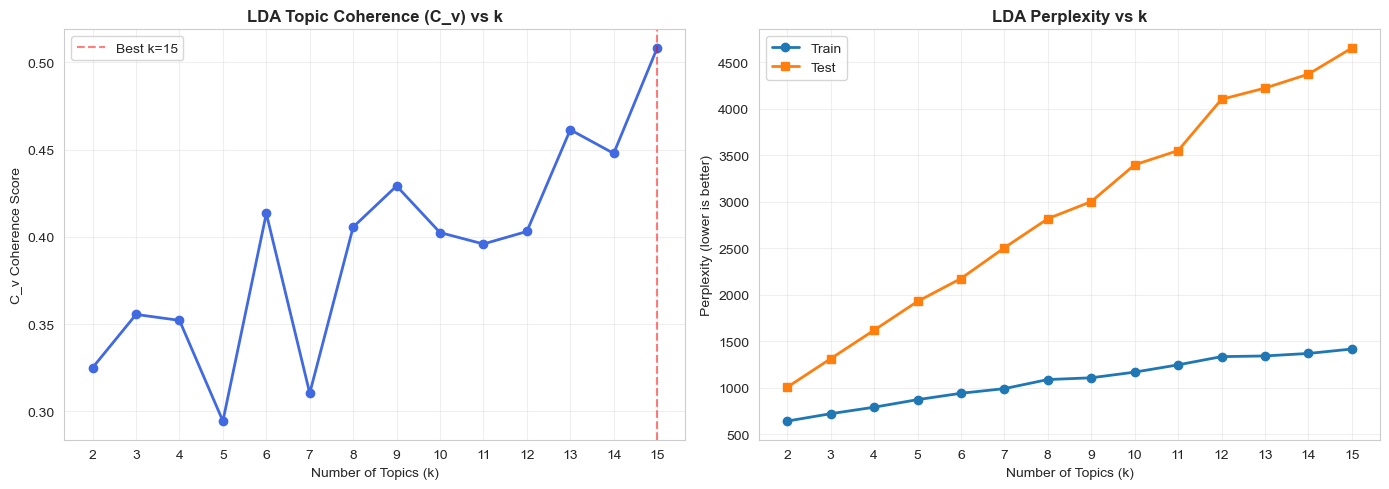


Best k by C_v coherence: 15 (C_v = 0.5082)


In [27]:
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary

# Build gensim dictionary and corpus from the TRAIN tokens
train_token_lists = [tokens.iloc[i] for i in train_idx]
test_token_lists = [tokens.iloc[i] for i in test_idx]

gensim_dict = Dictionary(train_token_lists)
gensim_dict.filter_extremes(no_below=3, no_above=0.85)
gensim_corpus = [gensim_dict.doc2bow(doc) for doc in train_token_lists]

k_range = range(2, 16)
coherence_scores = []
perplexity_train_scores = []
perplexity_test_scores = []

print("=== LDA Sweep: k = 2..15 ===")
for k in k_range:
    lda_k = LatentDirichletAllocation(
        n_components=k, random_state=42, max_iter=20, learning_method='online'
    )
    lda_k.fit(X_lda_train)
    perplexity_train_scores.append(lda_k.perplexity(X_lda_train))
    perplexity_test_scores.append(lda_k.perplexity(X_lda_test))

    topic_words = []
    for topic in lda_k.components_:
        top_idx = topic.argsort()[-10:][::-1]
        topic_words.append([feature_names_lda[i] for i in top_idx])

    cm = CoherenceModel(
        topics=topic_words, texts=train_token_lists,
        dictionary=gensim_dict, coherence='c_v'
    )
    c_v = cm.get_coherence()
    coherence_scores.append(c_v)
    print(f"  k={k:2d}  C_v={c_v:.4f}  train_perp={perplexity_train_scores[-1]:.1f}  test_perp={perplexity_test_scores[-1]:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), coherence_scores, marker='o', linewidth=2, color='royalblue')
axes[0].set_title('LDA Topic Coherence (C_v) vs k', fontweight='bold')
axes[0].set_xlabel('Number of Topics (k)')
axes[0].set_ylabel('C_v Coherence Score')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)
best_k_cv = list(k_range)[np.argmax(coherence_scores)]
axes[0].axvline(best_k_cv, color='red', linestyle='--', alpha=0.5, label=f'Best k={best_k_cv}')
axes[0].legend()

axes[1].plot(list(k_range), perplexity_train_scores, marker='o', linewidth=2, label='Train')
axes[1].plot(list(k_range), perplexity_test_scores, marker='s', linewidth=2, label='Test')
axes[1].set_title('LDA Perplexity vs k', fontweight='bold')
axes[1].set_xlabel('Number of Topics (k)')
axes[1].set_ylabel('Perplexity (lower is better)')
axes[1].set_xticks(list(k_range))
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()
print(f"\nBest k by C_v coherence: {best_k_cv} (C_v = {max(coherence_scores):.4f})")

## 6.2 LDA Topic Assignment Confidence

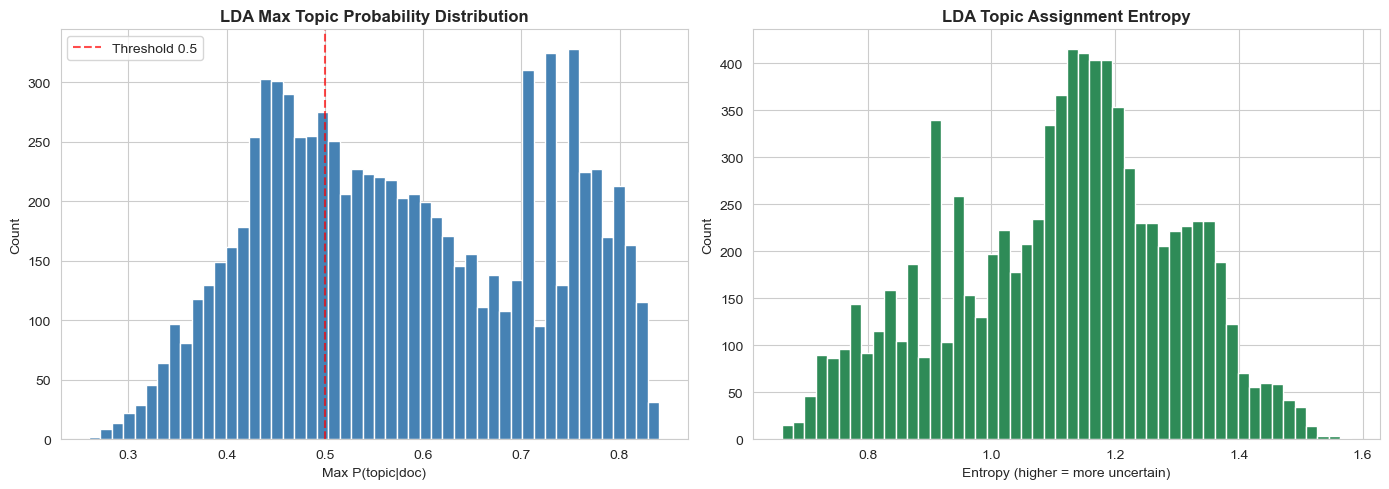

Docs with confident assignment (max_prob > 0.5): 65.2%
Mean entropy: 1.112
Mean max probability: 0.580


In [28]:
from scipy.stats import entropy

lda_topic_dist = np.empty((len(df), 5))
lda_topic_dist[train_idx] = lda_train_topics
lda_topic_dist[test_idx] = lda_test_topics

df['lda_entropy'] = [entropy(row) for row in lda_topic_dist]
df['lda_max_prob'] = lda_topic_dist.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['lda_max_prob'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('LDA Max Topic Probability Distribution', fontweight='bold')
axes[0].set_xlabel('Max P(topic|doc)')
axes[0].set_ylabel('Count')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='Threshold 0.5')
axes[0].legend()

axes[1].hist(df['lda_entropy'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('LDA Topic Assignment Entropy', fontweight='bold')
axes[1].set_xlabel('Entropy (higher = more uncertain)')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

confident = (df['lda_max_prob'] > 0.5).mean()
print(f"Docs with confident assignment (max_prob > 0.5): {confident:.1%}")
print(f"Mean entropy: {df['lda_entropy'].mean():.3f}")
print(f"Mean max probability: {df['lda_max_prob'].mean():.3f}")

## 6.3 BERTopic Evaluation

In [29]:
print("=" * 60)
print("BERTOPIC EVALUATION")
print("=" * 60)

bt_all = topics_all.copy()
n_outliers = (bt_all == -1).sum()
n_total = len(bt_all)
print(f"Outliers: {n_outliers} / {n_total} ({n_outliers/n_total:.1%})")

bt_valid = bt_all[bt_all != -1]
unique_topics, topic_counts = np.unique(bt_valid, return_counts=True)
print(f"\nValid topics found: {len(unique_topics)}")
for t, c in sorted(zip(unique_topics, topic_counts), key=lambda x: -x[1]):
    pct = c / len(bt_valid) * 100
    print(f"  Topic {t}: {c} docs ({pct:.1f}%)")
    if pct > 50:
        print(f"    ⚠ MEGA-TOPIC: contains >{pct:.0f}% of non-outlier docs")

sorted_counts = sorted(topic_counts, reverse=True)
if len(sorted_counts) >= 2:
    dominance = sorted_counts[0] / sorted_counts[1]
    print(f"\nDominance ratio (largest/2nd): {dominance:.1f}x")

if n_outliers > 0:
    outlier_lengths = df.loc[bt_all == -1, 'word_count']
    non_outlier_lengths = df.loc[bt_all != -1, 'word_count']
    print(f"\nOutlier mean word count: {outlier_lengths.mean():.1f}")
    print(f"Non-outlier mean word count: {non_outlier_lengths.mean():.1f}")

BERTOPIC EVALUATION
Outliers: 872 / 8469 (10.3%)

Valid topics found: 9
  Topic 0: 4608 docs (60.7%)
    ⚠ MEGA-TOPIC: contains >61% of non-outlier docs
  Topic 1: 526 docs (6.9%)
  Topic 2: 516 docs (6.8%)
  Topic 3: 474 docs (6.2%)
  Topic 4: 452 docs (5.9%)
  Topic 5: 334 docs (4.4%)
  Topic 6: 330 docs (4.3%)
  Topic 7: 188 docs (2.5%)
  Topic 8: 169 docs (2.2%)

Dominance ratio (largest/2nd): 8.8x

Outlier mean word count: 46.9
Non-outlier mean word count: 46.4


## 6.4 Axis 1 Head-to-Head: LDA vs BERTopic

In [30]:
print("=" * 60)
print("AXIS 1 COMPARISON: LDA vs BERTopic")
print("=" * 60)

def topic_purity(topic_labels, true_labels):
    purities = []
    for t in sorted(set(topic_labels)):
        mask = topic_labels == t
        if mask.sum() == 0:
            continue
        type_counts = pd.Series(true_labels[mask]).value_counts()
        purities.append(type_counts.iloc[0] / mask.sum())
    return np.mean(purities)

lda_purity = topic_purity(lda_labels, df['Ticket Type'].values)
bt_valid_mask = topics_all != -1
bt_purity = topic_purity(topics_all[bt_valid_mask], df['Ticket Type'].values[bt_valid_mask])

lda_ari_type = adjusted_rand_score(df['Ticket Type'], lda_labels)
lda_nmi_type = normalized_mutual_info_score(df['Ticket Type'], lda_labels)
bt_ari_type = adjusted_rand_score(df['Ticket Type'].values[bt_valid_mask], topics_all[bt_valid_mask])
bt_nmi_type = normalized_mutual_info_score(df['Ticket Type'].values[bt_valid_mask], topics_all[bt_valid_mask])

lda_ari_subj = adjusted_rand_score(df['Ticket Subject'], lda_labels)
lda_nmi_subj = normalized_mutual_info_score(df['Ticket Subject'], lda_labels)
bt_ari_subj = adjusted_rand_score(df['Ticket Subject'].values[bt_valid_mask], topics_all[bt_valid_mask])
bt_nmi_subj = normalized_mutual_info_score(df['Ticket Subject'].values[bt_valid_mask], topics_all[bt_valid_mask])

lda_train_perp = lda_5.perplexity(X_lda_train)
lda_test_perp = lda_5.perplexity(X_lda_test)

comparison = pd.DataFrame({
    'Metric': ['Topics Found', 'Outlier %', 'Mean Topic Purity (Type)',
               'ARI vs Ticket Type', 'NMI vs Ticket Type',
               'ARI vs Ticket Subject', 'NMI vs Ticket Subject',
               'Train Perplexity', 'Test Perplexity'],
    'LDA (k=5)': [5, '0.0%', f'{lda_purity:.3f}',
                   f'{lda_ari_type:.4f}', f'{lda_nmi_type:.4f}',
                   f'{lda_ari_subj:.4f}', f'{lda_nmi_subj:.4f}',
                   f'{lda_train_perp:.1f}', f'{lda_test_perp:.1f}'],
    'BERTopic': [len(unique_topics), f'{n_outliers/n_total:.1%}', f'{bt_purity:.3f}',
                 f'{bt_ari_type:.4f}', f'{bt_nmi_type:.4f}',
                 f'{bt_ari_subj:.4f}', f'{bt_nmi_subj:.4f}',
                 'N/A', 'N/A']
})
print(comparison.to_string(index=False))

AXIS 1 COMPARISON: LDA vs BERTopic
                  Metric LDA (k=5) BERTopic
            Topics Found         5        9
               Outlier %      0.0%    10.3%
Mean Topic Purity (Type)     0.218    0.223
      ARI vs Ticket Type    0.0005   0.0002
      NMI vs Ticket Type    0.0011   0.0010
   ARI vs Ticket Subject   -0.0001   0.0001
   NMI vs Ticket Subject    0.0013   0.0033
        Train Perplexity     872.5      N/A
         Test Perplexity    1927.8      N/A


## 6.5 Axis 2 Evaluation: VADER vs TextBlob

In [31]:
print("=" * 60)
print("AXIS 2 EVALUATION: VADER vs TextBlob")
print("=" * 60)

from scipy.stats import kruskal

print(f"\nVADER compound — mean: {df['vader_compound'].mean():.3f}, "
      f"std: {df['vader_compound'].std():.3f}, "
      f"range: [{df['vader_compound'].min():.3f}, {df['vader_compound'].max():.3f}]")
print(f"TextBlob polarity — mean: {df['tb_polarity'].mean():.3f}, "
      f"std: {df['tb_polarity'].std():.3f}, "
      f"range: [{df['tb_polarity'].min():.3f}, {df['tb_polarity'].max():.3f}]")

print("\nVADER label distribution:")
print(df['vader_label'].value_counts(normalize=True).round(3))
print("\nTextBlob label distribution:")
print(df['tb_label'].value_counts(normalize=True).round(3))

groups_vader = [g['vader_compound'].values for _, g in df.groupby('Ticket Type')]
groups_tb = [g['tb_polarity'].values for _, g in df.groupby('Ticket Type')]
stat_v, p_v = kruskal(*groups_vader)
stat_t, p_t = kruskal(*groups_tb)
print(f"\nKruskal-Wallis (sentiment ~ Ticket Type):")
print(f"  VADER:    H={stat_v:.2f}, p={p_v:.4f} {'→ no significant difference' if p_v > 0.05 else '→ significant difference'}")
print(f"  TextBlob: H={stat_t:.2f}, p={p_t:.4f} {'→ no significant difference' if p_t > 0.05 else '→ significant difference'}")

groups_vader_subj = [g['vader_compound'].values for _, g in df.groupby('Ticket Subject')]
groups_tb_subj = [g['tb_polarity'].values for _, g in df.groupby('Ticket Subject')]
stat_vs, p_vs = kruskal(*groups_vader_subj)
stat_ts, p_ts = kruskal(*groups_tb_subj)
print(f"\nKruskal-Wallis (sentiment ~ Ticket Subject):")
print(f"  VADER:    H={stat_vs:.2f}, p={p_vs:.4f} {'→ no significant difference' if p_vs > 0.05 else '→ significant difference'}")
print(f"  TextBlob: H={stat_ts:.2f}, p={p_ts:.4f} {'→ no significant difference' if p_ts > 0.05 else '→ significant difference'}")

AXIS 2 EVALUATION: VADER vs TextBlob

VADER compound — mean: 0.256, std: 0.422, range: [-0.955, 0.985]
TextBlob polarity — mean: 0.060, std: 0.202, range: [-0.750, 1.000]

VADER label distribution:
vader_label
Positive    0.708
Negative    0.249
Neutral     0.043
Name: proportion, dtype: float64

TextBlob label distribution:
tb_label
Positive    0.445
Neutral     0.330
Negative    0.225
Name: proportion, dtype: float64

Kruskal-Wallis (sentiment ~ Ticket Type):
  VADER:    H=1.58, p=0.8119 → no significant difference
  TextBlob: H=2.25, p=0.6900 → no significant difference

Kruskal-Wallis (sentiment ~ Ticket Subject):
  VADER:    H=13.05, p=0.5987 → no significant difference
  TextBlob: H=12.14, p=0.6685 → no significant difference


## 6.6 Sentiment × Topic Interaction

SENTIMENT × TOPIC INTERACTION


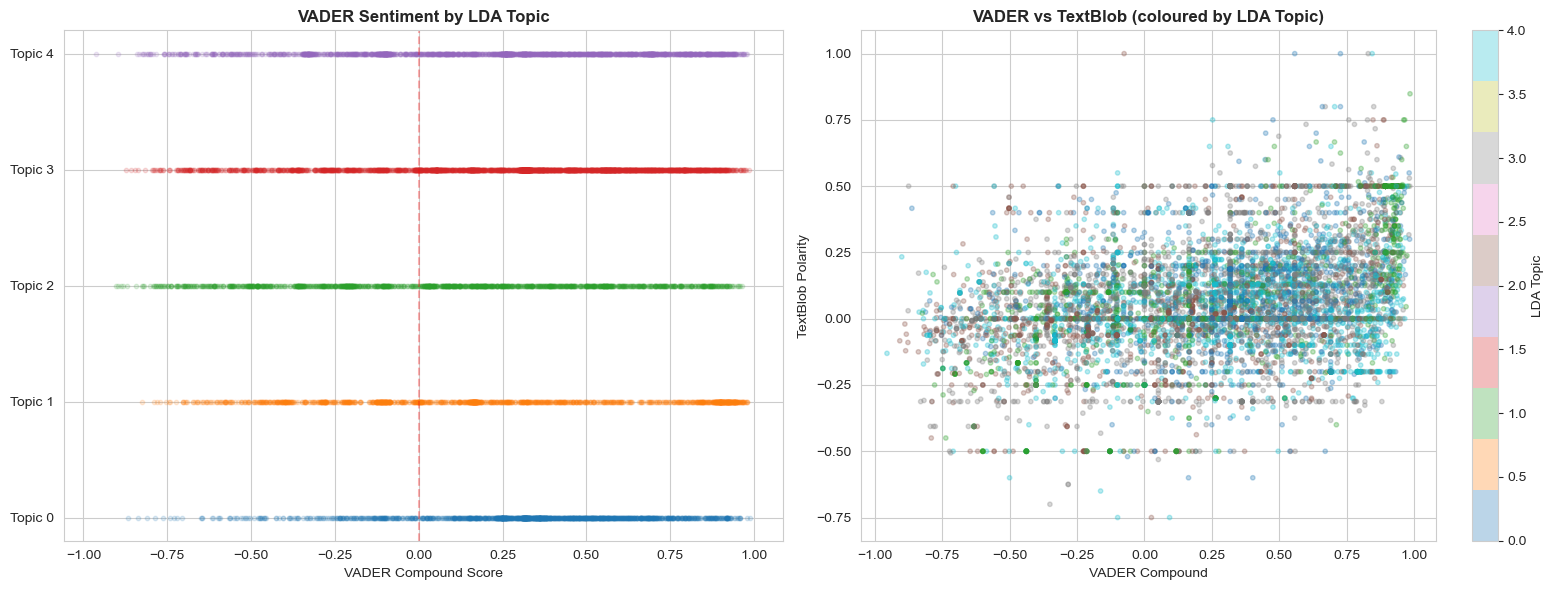

In [32]:
print("=" * 60)
print("SENTIMENT × TOPIC INTERACTION")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for topic_id in range(5):
    mask = df['lda_topic'] == topic_id
    axes[0].scatter(
        df.loc[mask, 'vader_compound'] + np.random.normal(0, 0.01, mask.sum()),
        [topic_id] * mask.sum(), alpha=0.15, s=10
    )
axes[0].set_yticks(range(5))
axes[0].set_yticklabels([f'Topic {i}' for i in range(5)])
axes[0].set_xlabel('VADER Compound Score')
axes[0].set_title('VADER Sentiment by LDA Topic', fontweight='bold')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.3)

scatter = axes[1].scatter(
    df['vader_compound'], df['tb_polarity'],
    c=df['lda_topic'], cmap='tab10', alpha=0.3, s=10
)
axes[1].set_xlabel('VADER Compound')
axes[1].set_ylabel('TextBlob Polarity')
axes[1].set_title('VADER vs TextBlob (coloured by LDA Topic)', fontweight='bold')
plt.colorbar(scatter, ax=axes[1], label='LDA Topic')
plt.tight_layout()
plt.show()

## 6.7 Consistency & Robustness Across Methods (Req 4a)

4a. COMPREHENSIVE CONSISTENCY & ROBUSTNESS

--- Algorithm Consistency (KMeans vs HAC, same representation) ---
  TF-IDF:  ARI = -0.0939
  SBERT:   ARI = -0.0003

--- Representation Consistency (TF-IDF vs SBERT, same algorithm) ---
  KMeans:  ARI = 0.0600
  HAC:     ARI = -0.0009

--- BERTopic vs Clustering ---
  BERTopic vs TF-IDF KMeans: ARI = 0.0282
  BERTopic vs SBERT KMeans:  ARI = 0.3554

--- LDA Robustness (5 random seeds, k=5) ---
  Pairwise ARI across 5 seeds: mean=0.0779, min=0.0560, max=0.1218
  → LDA assignments are UNSTABLE — topics shift with initialisation

--- Full Cross-Method Agreement Matrix (ARI) ---
           KM-TF   KM-SB  HAC-TF  HAC-SB     LDA  BERTopic
KM-TF     1.0000  0.0600 -0.0939 -0.0006  0.0177    0.0357
KM-SB     0.0600  1.0000 -0.0252 -0.0003  0.1231    0.2959
HAC-TF   -0.0939 -0.0252  1.0000 -0.0009  0.0237   -0.0573
HAC-SB   -0.0006 -0.0003 -0.0009  1.0000 -0.0001   -0.0006
LDA       0.0177  0.1231  0.0237 -0.0001  1.0000    0.0820
BERTopic  0.0357  0

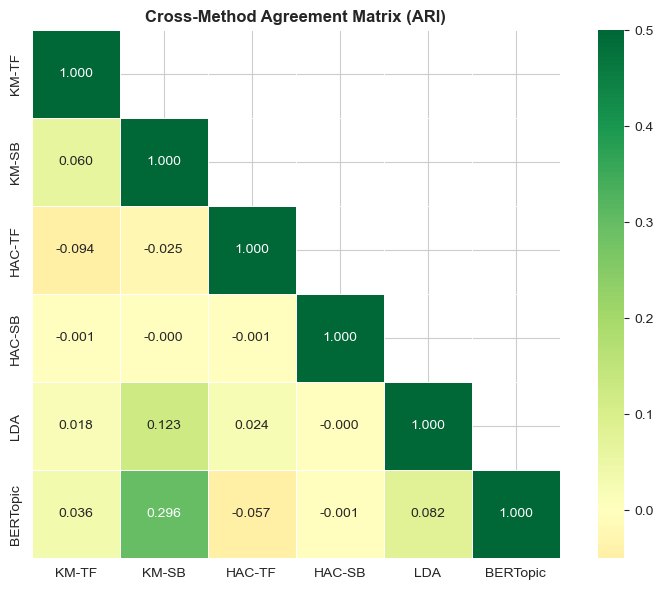

In [33]:
print("=" * 60)
print("4a. COMPREHENSIVE CONSISTENCY & ROBUSTNESS")
print("=" * 60)

# ---- 1. Clustering algorithm consistency: KMeans vs HAC (same repr) ----
from sklearn.cluster import AgglomerativeClustering

hac_tfidf_5 = AgglomerativeClustering(n_clusters=5, metric='cosine', linkage='average')
hac_tfidf_labels = hac_tfidf_5.fit_predict(X_tfidf.toarray())

hac_sbert_5 = AgglomerativeClustering(n_clusters=5, metric='cosine', linkage='average')
hac_sbert_labels = hac_sbert_5.fit_predict(X_sbert)

ari_km_hac_tfidf = adjusted_rand_score(km_tfidf_labels, hac_tfidf_labels)
ari_km_hac_sbert = adjusted_rand_score(km_sbert_labels, hac_sbert_labels)
print("\n--- Algorithm Consistency (KMeans vs HAC, same representation) ---")
print(f"  TF-IDF:  ARI = {ari_km_hac_tfidf:.4f}")
print(f"  SBERT:   ARI = {ari_km_hac_sbert:.4f}")

# ---- 2. Representation consistency: TF-IDF vs SBERT (same algorithm) ----
ari_tfidf_sbert_km = adjusted_rand_score(km_tfidf_labels, km_sbert_labels)
ari_tfidf_sbert_hac = adjusted_rand_score(hac_tfidf_labels, hac_sbert_labels)
print("\n--- Representation Consistency (TF-IDF vs SBERT, same algorithm) ---")
print(f"  KMeans:  ARI = {ari_tfidf_sbert_km:.4f}")
print(f"  HAC:     ARI = {ari_tfidf_sbert_hac:.4f}")

# ---- 3. BERTopic vs clustering ----
bt_valid_mask = topics_all != -1
ari_bt_km_tfidf = adjusted_rand_score(km_tfidf_labels[bt_valid_mask], topics_all[bt_valid_mask])
ari_bt_km_sbert = adjusted_rand_score(km_sbert_labels[bt_valid_mask], topics_all[bt_valid_mask])
print("\n--- BERTopic vs Clustering ---")
print(f"  BERTopic vs TF-IDF KMeans: ARI = {ari_bt_km_tfidf:.4f}")
print(f"  BERTopic vs SBERT KMeans:  ARI = {ari_bt_km_sbert:.4f}")

# ---- 4. LDA Robustness: stability across random seeds ----
print("\n--- LDA Robustness (5 random seeds, k=5) ---")
from sklearn.decomposition import LatentDirichletAllocation

seed_labels = []
for seed in [0, 7, 21, 42, 99]:
    lda_s = LatentDirichletAllocation(
        n_components=5, random_state=seed, max_iter=20, learning_method='online'
    )
    topics_s = lda_s.fit_transform(X_lda_train)
    labels_s = np.empty(len(df), dtype=int)
    labels_s[train_idx] = topics_s.argmax(axis=1)
    labels_s[test_idx] = lda_s.transform(X_lda_test).argmax(axis=1)
    seed_labels.append(labels_s)

# Pairwise ARI between seeds
from itertools import combinations
seed_aris = []
for (i, l1), (j, l2) in combinations(enumerate(seed_labels), 2):
    seed_aris.append(adjusted_rand_score(l1, l2))

print(f"  Pairwise ARI across 5 seeds: mean={np.mean(seed_aris):.4f}, "
      f"min={np.min(seed_aris):.4f}, max={np.max(seed_aris):.4f}")
if np.mean(seed_aris) > 0.8:
    print("  → LDA assignments are STABLE across seeds")
elif np.mean(seed_aris) > 0.5:
    print("  → LDA assignments are MODERATELY stable")
else:
    print("  → LDA assignments are UNSTABLE — topics shift with initialisation")

# ---- 5. Full cross-method agreement matrix ----
print("\n--- Full Cross-Method Agreement Matrix (ARI) ---")
all_label_sets = {
    'KM-TF': km_tfidf_labels,
    'KM-SB': km_sbert_labels,
    'HAC-TF': hac_tfidf_labels,
    'HAC-SB': hac_sbert_labels,
    'LDA': lda_labels,
}
# Add BERTopic with -1 mapped to a separate cluster for fair comparison
bt_for_compare = topics_all.copy()
bt_for_compare[bt_for_compare == -1] = 99  # outlier cluster
all_label_sets['BERTopic'] = bt_for_compare

methods = list(all_label_sets.keys())
ari_matrix = pd.DataFrame(np.zeros((len(methods), len(methods))),
                           index=methods, columns=methods)
for i, m1 in enumerate(methods):
    for j, m2 in enumerate(methods):
        if i == j:
            ari_matrix.iloc[i, j] = 1.0
        elif i < j:
            a = adjusted_rand_score(all_label_sets[m1], all_label_sets[m2])
            ari_matrix.iloc[i, j] = a
            ari_matrix.iloc[j, i] = a

print(ari_matrix.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(ari_matrix, dtype=bool), k=1)
sns.heatmap(ari_matrix.astype(float), annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-0.05, vmax=0.5, ax=ax, mask=mask,
            square=True, linewidths=0.5)
ax.set_title('Cross-Method Agreement Matrix (ARI)', fontweight='bold')
plt.tight_layout()
plt.show()


## 6.8 Coherence & Interpretability of Issue Categories (Req 4b)

4b. COHERENCE & INTERPRETABILITY OF ISSUE CATEGORIES

--- LDA Per-Topic Coherence (C_v, k=5) ---
  Topic 0 (C_v=0.2704): user, remain, unresolved, mention, contact, manual
  Topic 1 (C_v=0.2905): different, ensure, security, safe, access, concerned
  Topic 2 (C_v=0.3566): network, change, connect, recent, occur, password
  Topic 3 (C_v=0.3351): update, notice, error, soon, assistance, affect
  Topic 4 (C_v=0.2196): factory, hoping, work, intermittent, act, unexpectedly

  Overall C_v: 0.2944

--- BERTopic Per-Topic Coherence (C_v) ---
  Topic 0 (C_v=0.6466): the, product, issue, please, with, an
  Topic 1 (C_v=0.6677): software, bug, in, the, it, to
  Topic 2 (C_v=0.7469): to, network, troubleshoot, networks, this, connecting
  Topic 3 (C_v=0.3739): data, files, deleted, have, them, to
  Topic 4 (C_v=0.9182): account, my, password, it, how, to
  Topic 5 (C_v=0.1684): the, desired, through, find, guide, action
  Topic 6 (C_v=0.9996): concerned, safe, ensure, security, like, about
  Topi

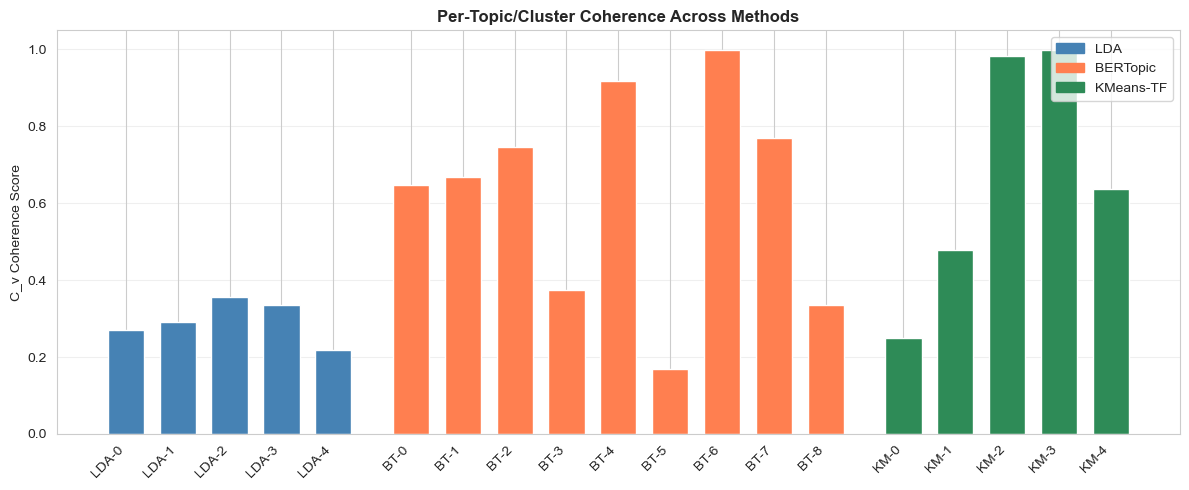

In [34]:
print("=" * 60)
print("4b. COHERENCE & INTERPRETABILITY OF ISSUE CATEGORIES")
print("=" * 60)

from gensim.models import CoherenceModel
from gensim.corpora import Dictionary

# Rebuild gensim objects if not in scope
train_token_lists = [tokens.iloc[i] for i in train_idx]
gensim_dict = Dictionary(train_token_lists)
gensim_dict.filter_extremes(no_below=3, no_above=0.85)

# ---- 1. LDA per-topic coherence (k=5) ----
print("\n--- LDA Per-Topic Coherence (C_v, k=5) ---")
lda_topic_words = []
for topic in lda_5.components_:
    top_idx = topic.argsort()[-10:][::-1]
    lda_topic_words.append([feature_names_lda[i] for i in top_idx])

cm_lda = CoherenceModel(
    topics=lda_topic_words, texts=train_token_lists,
    dictionary=gensim_dict, coherence='c_v'
)
per_topic_cv = cm_lda.get_coherence_per_topic()
overall_cv = cm_lda.get_coherence()

for t, (words, cv) in enumerate(zip(lda_topic_words, per_topic_cv)):
    print(f"  Topic {t} (C_v={cv:.4f}): {', '.join(words[:6])}")
print(f"\n  Overall C_v: {overall_cv:.4f}")

# ---- 2. BERTopic topic coherence ----
print("\n--- BERTopic Per-Topic Coherence (C_v) ---")
bt_topic_info = topic_model.get_topic_info()
bt_topic_words = []
bt_topic_ids = []
for _, row in bt_topic_info.iterrows():
    if row['Topic'] == -1:
        continue
    words = [w for w, _ in topic_model.get_topic(row['Topic'])[:10]]
    bt_topic_words.append(words)
    bt_topic_ids.append(row['Topic'])

if bt_topic_words:
    cm_bt = CoherenceModel(
        topics=bt_topic_words, texts=train_token_lists,
        dictionary=gensim_dict, coherence='c_v'
    )
    bt_per_topic_cv = cm_bt.get_coherence_per_topic()
    bt_overall_cv = cm_bt.get_coherence()
    for tid, words, cv in zip(bt_topic_ids, bt_topic_words, bt_per_topic_cv):
        print(f"  Topic {tid} (C_v={cv:.4f}): {', '.join(words[:6])}")
    print(f"\n  Overall C_v: {bt_overall_cv:.4f}")
else:
    bt_overall_cv = float('nan')
    print("  No valid BERTopic topics for coherence calculation")

# ---- 3. Clustering interpretability via top TF-IDF terms ----
print("\n--- Cluster Interpretability: Top TF-IDF Terms per Cluster ---")
feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()
X_tfidf_dense = X_tfidf.toarray()

cluster_topic_words = []
for method_name, labels in [('KMeans-TF', km_tfidf_labels), ('HAC-TF', hac_tfidf_labels)]:
    print(f"\n  {method_name}:")
    method_words = []
    for c in sorted(set(labels)):
        mask = labels == c
        centroid = X_tfidf_dense[mask].mean(axis=0)
        top_idx = centroid.argsort()[-10:][::-1]
        words = [feature_names_tfidf[i] for i in top_idx]
        method_words.append(words)
        print(f"    Cluster {c}: {', '.join(words[:6])}")
    cluster_topic_words.append((method_name, method_words))

# Coherence for KMeans-TF clusters
km_cluster_words = cluster_topic_words[0][1]
cm_km = CoherenceModel(
    topics=km_cluster_words, texts=train_token_lists,
    dictionary=gensim_dict, coherence='c_v'
)
km_cv = cm_km.get_coherence()
km_per_cv = cm_km.get_coherence_per_topic()
print(f"\n  KMeans-TF Overall C_v: {km_cv:.4f}")
for c, cv in enumerate(km_per_cv):
    print(f"    Cluster {c}: C_v = {cv:.4f}")

# ---- 4. Summary comparison ----
print("\n--- Coherence Comparison Summary ---")
coherence_summary = pd.DataFrame({
    'Method': ['LDA (k=5)', 'BERTopic', 'KMeans-TF (k=5)'],
    'Overall C_v': [f'{overall_cv:.4f}', f'{bt_overall_cv:.4f}' if not np.isnan(bt_overall_cv) else 'N/A', f'{km_cv:.4f}'],
    'Topics/Clusters': [5, len(bt_topic_ids), 5],
    'Coverage': ['100%', f'{(bt_valid_mask).mean():.1%}', '100%'],
})
print(coherence_summary.to_string(index=False))

# ---- 5. Visualise per-topic coherence ----
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = 0
colors_map = {'LDA': 'steelblue', 'BERTopic': 'coral', 'KMeans-TF': 'seagreen'}
tick_labels = []
tick_positions = []

for cv_val in per_topic_cv:
    ax.bar(x_pos, cv_val, color='steelblue', width=0.7)
    tick_labels.append(f'LDA-{x_pos}')
    tick_positions.append(x_pos)
    x_pos += 1

x_pos += 0.5  # gap
if bt_topic_words:
    for i, cv_val in enumerate(bt_per_topic_cv):
        ax.bar(x_pos, cv_val, color='coral', width=0.7)
        tick_labels.append(f'BT-{bt_topic_ids[i]}')
        tick_positions.append(x_pos)
        x_pos += 1

x_pos += 0.5
for i, cv_val in enumerate(km_per_cv):
    ax.bar(x_pos, cv_val, color='seagreen', width=0.7)
    tick_labels.append(f'KM-{i}')
    tick_positions.append(x_pos)
    x_pos += 1

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')
ax.set_ylabel('C_v Coherence Score')
ax.set_title('Per-Topic/Cluster Coherence Across Methods', fontweight='bold')
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='steelblue', label='LDA'),
    plt.Rectangle((0,0),1,1, color='coral', label='BERTopic'),
    plt.Rectangle((0,0),1,1, color='seagreen', label='KMeans-TF'),
], loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 6.9 Alignment with Expected Patterns & Initial Clustering (Req 4c)

4c. ALIGNMENT WITH EXPECTED PATTERNS & INITIAL CLUSTERING

--- All Methods vs Ground Truth ---
   Method Coverage ARI(Type) NMI(Type) ARI(Subj) NMI(Subj)
KMeans-TF     100%   -0.0001    0.0006   -0.0001    0.0016
KMeans-SB     100%    0.0001    0.0005    0.0001    0.0016
   HAC-TF     100%   -0.0000    0.0010    0.0000    0.0021
   HAC-SB     100%   -0.0000    0.0009    0.0000    0.0009
      LDA     100%    0.0005    0.0011   -0.0001    0.0013
 BERTopic    89.7%    0.0002    0.0010    0.0001    0.0033


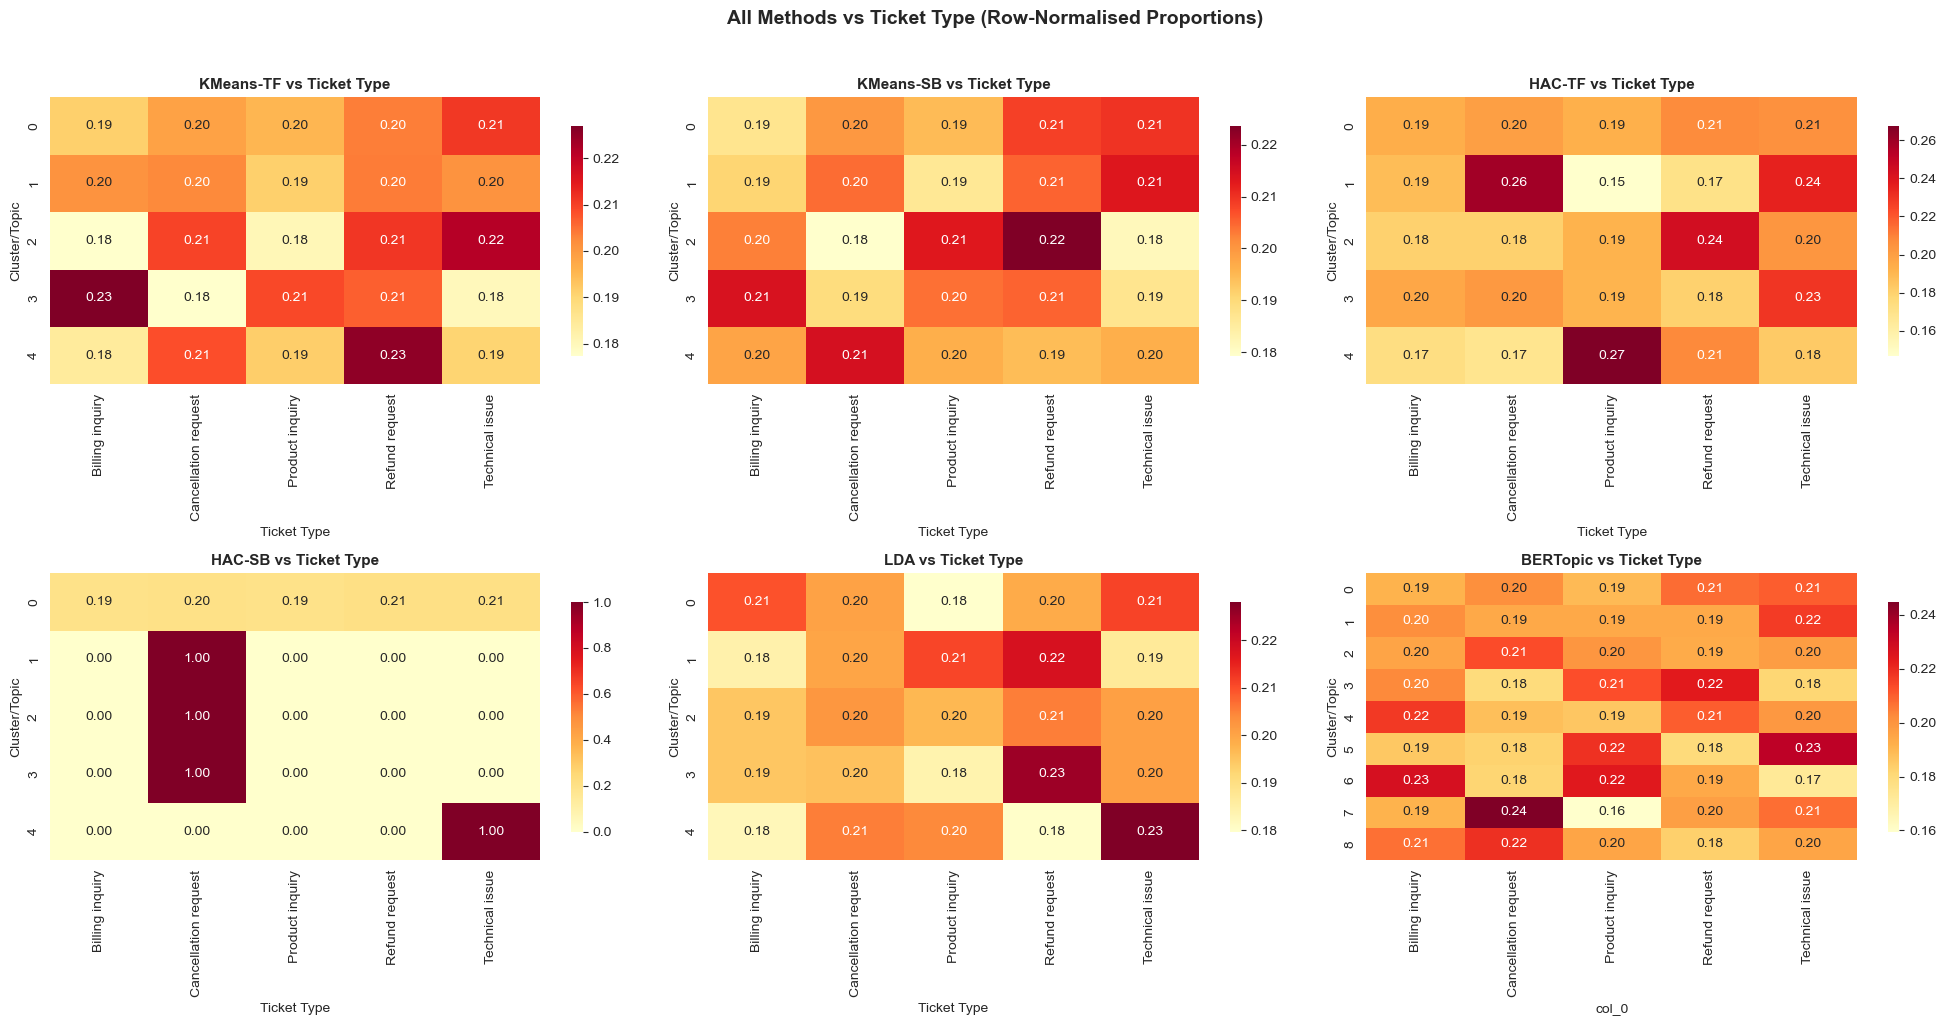


--- Pattern Analysis: LDA Topics vs Intuitive Issue Categories ---
(Checking if discovered topics correspond to recognisable themes)

  Topic 0 (1402 docs):
    Keywords: user, remain, unresolved, mention, contact, manual, time, delete
    Ticket Type distribution (entropy=1.61):
      Technical issue: 296 (21.1%)
      Billing inquiry: 294 (21.0%)
      Cancellation request: 281 (20.0%)
    Ticket Subject distribution (entropy=2.77):
      Battery life: 106 (7.6%)
      Refund request: 104 (7.4%)
      Product recommendation: 96 (6.8%)
    Top products: Canon EOS (44), Microsoft Office (43)
    → Mixed topic: spans multiple ticket types equally

  Topic 1 (1285 docs):
    Keywords: different, ensure, security, safe, access, concerned, configuration, model
    Ticket Type distribution (entropy=1.61):
      Refund request: 280 (21.8%)
      Product inquiry: 271 (21.1%)
      Cancellation request: 257 (20.0%)
    Ticket Subject distribution (entropy=2.77):
      Software bug: 104 (8.1%)

In [35]:
from scipy.stats import entropy

print("=" * 60)
print("4c. ALIGNMENT WITH EXPECTED PATTERNS & INITIAL CLUSTERING")
print("=" * 60)

# ---- 1. Every method vs ground truth (Ticket Type & Ticket Subject) ----
print("\n--- All Methods vs Ground Truth ---")

all_methods = {
    'KMeans-TF': km_tfidf_labels,
    'KMeans-SB': km_sbert_labels,
    'HAC-TF': hac_tfidf_labels,
    'HAC-SB': hac_sbert_labels,
    'LDA': lda_labels,
    'BERTopic': topics_all,
}

rows = []
for name, labels in all_methods.items():
    if name == 'BERTopic':
        valid = labels != -1
        ari_type = adjusted_rand_score(df['Ticket Type'].values[valid], labels[valid])
        nmi_type = normalized_mutual_info_score(df['Ticket Type'].values[valid], labels[valid])
        ari_subj = adjusted_rand_score(df['Ticket Subject'].values[valid], labels[valid])
        nmi_subj = normalized_mutual_info_score(df['Ticket Subject'].values[valid], labels[valid])
        coverage = f'{valid.mean():.1%}'
    else:
        ari_type = adjusted_rand_score(df['Ticket Type'], labels)
        nmi_type = normalized_mutual_info_score(df['Ticket Type'], labels)
        ari_subj = adjusted_rand_score(df['Ticket Subject'], labels)
        nmi_subj = normalized_mutual_info_score(df['Ticket Subject'], labels)
        coverage = '100%'
    rows.append({
        'Method': name, 'Coverage': coverage,
        'ARI(Type)': f'{ari_type:.4f}', 'NMI(Type)': f'{nmi_type:.4f}',
        'ARI(Subj)': f'{ari_subj:.4f}', 'NMI(Subj)': f'{nmi_subj:.4f}',
    })

alignment_df = pd.DataFrame(rows)
print(alignment_df.to_string(index=False))

# ---- 2. Visualise: heatmaps for every method vs Ticket Type ----
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for idx, (name, labels) in enumerate(all_methods.items()):
    if idx >= 6:
        break
    if name == 'BERTopic':
        valid = labels != -1
        ct = pd.crosstab(labels[valid], df['Ticket Type'].values[valid])
    else:
        ct = pd.crosstab(labels, df['Ticket Type'])
    ct_norm = ct.div(ct.sum(axis=1), axis=0)
    sns.heatmap(ct_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[idx],
                cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f'{name} vs Ticket Type', fontweight='bold', fontsize=11)
    axes[idx].set_ylabel('Cluster/Topic')

plt.suptitle('All Methods vs Ticket Type (Row-Normalised Proportions)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ---- 3. Do LDA topics map to intuitive issue categories? ----
print("\n--- Pattern Analysis: LDA Topics vs Intuitive Issue Categories ---")
print("(Checking if discovered topics correspond to recognisable themes)\n")

for t in range(5):
    mask = df['lda_topic'] == t
    n = mask.sum()

    # Top words
    top_idx = lda_5.components_[t].argsort()[-8:][::-1]
    top_words = [feature_names_lda[i] for i in top_idx]

    # Dominant ticket type and subject
    type_mode = df.loc[mask, 'Ticket Type'].value_counts()
    subj_mode = df.loc[mask, 'Ticket Subject'].value_counts()
    type_entropy = entropy(type_mode.values / type_mode.sum())
    subj_entropy = entropy(subj_mode.values / subj_mode.sum())

    # Top products
    top_product = df.loc[mask, 'Product Purchased'].value_counts().head(2)

    print(f"  Topic {t} ({n} docs):")
    print(f"    Keywords: {', '.join(top_words)}")
    print(f"    Ticket Type distribution (entropy={type_entropy:.2f}):")
    for tt, c in type_mode.head(3).items():
        print(f"      {tt}: {c} ({c/n*100:.1f}%)")
    print(f"    Ticket Subject distribution (entropy={subj_entropy:.2f}):")
    for ts, c in subj_mode.head(3).items():
        print(f"      {ts}: {c} ({c/n*100:.1f}%)")
    print(f"    Top products: {', '.join([f'{p} ({c})' for p, c in top_product.items()])}")

    if type_entropy > 1.3:
        print(f"    → Mixed topic: spans multiple ticket types equally")
    else:
        print(f"    → Skewed toward: {type_mode.index[0]}")
    print()

# ---- 4. Topic-to-clustering alignment detail ----
print("--- LDA Topic ↔ Clustering Alignment Detail ---")
print("For each LDA topic, which cluster(s) does it overlap with most?\n")

for t in range(5):
    lda_mask = lda_labels == t
    # Find dominant KMeans-TF cluster
    km_in_topic = km_tfidf_labels[lda_mask]
    km_mode = pd.Series(km_in_topic).value_counts()
    overlap_pct = km_mode.iloc[0] / lda_mask.sum() * 100

    # Same for SBERT
    sb_in_topic = km_sbert_labels[lda_mask]
    sb_mode = pd.Series(sb_in_topic).value_counts()
    sb_overlap_pct = sb_mode.iloc[0] / lda_mask.sum() * 100

    print(f"  LDA Topic {t}:")
    print(f"    Best TF-IDF cluster match: Cluster {km_mode.index[0]} ({overlap_pct:.1f}% overlap)")
    print(f"    Best SBERT cluster match:  Cluster {sb_mode.index[0]} ({sb_overlap_pct:.1f}% overlap)")
    if overlap_pct > 50:
        print(f"    → Strong alignment with TF-IDF clustering")
    else:
        print(f"    → Weak alignment — topic spans multiple clusters")
    print()


# 7. Error Analysis

In [36]:
print("=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)

# 1. Sentiment disagreements
disagree_mask = df['vader_label'] != df['tb_label']
print(f"\nSentiment label disagreements: {disagree_mask.sum()} / {len(df)} ({disagree_mask.mean():.1%})")
print("\nDisagreement breakdown:")
print(pd.crosstab(df.loc[disagree_mask, 'vader_label'], df.loc[disagree_mask, 'tb_label'],
                   rownames=['VADER'], colnames=['TextBlob']))

print("\n--- Sample Disagreement Cases ---")
disagree_df = df[disagree_mask].sample(min(5, disagree_mask.sum()), random_state=42)
for _, row in disagree_df.iterrows():
    print(f"  VADER={row['vader_label']} ({row['vader_compound']:.3f}) | "
          f"TB={row['tb_label']} ({row['tb_polarity']:.3f})")
    print(f"  Text: {row['Ticket Description'][:150]}...")
    print()

# 2. LDA uncertain assignments
print("--- LDA Uncertain Assignments (entropy > 75th percentile) ---")
q75 = df['lda_entropy'].quantile(0.75)
uncertain = df[df['lda_entropy'] > q75].sample(min(5, (df['lda_entropy'] > q75).sum()), random_state=42)
for _, row in uncertain.iterrows():
    topic_dist = lda_topic_dist[row.name]
    top2 = topic_dist.argsort()[-2:][::-1]
    print(f"  Assigned: Topic {row['lda_topic']} (p={topic_dist[row['lda_topic']]:.2f}), "
          f"Runner-up: Topic {top2[1]} (p={topic_dist[top2[1]]:.2f})")
    print(f"  Text: {row['Ticket Description'][:150]}...")
    print()

# 3. BERTopic outliers
if (topics_all == -1).sum() > 0:
    print("--- BERTopic Outlier Samples ---")
    outlier_df = df[topics_all == -1].sample(min(5, (topics_all == -1).sum()), random_state=42)
    for _, row in outlier_df.iterrows():
        print(f"  Type: {row['Ticket Type']} | Subject: {row['Ticket Subject']}")
        print(f"  Text: {row['Ticket Description'][:150]}...")
        print()

ERROR ANALYSIS

Sentiment label disagreements: 4607 / 8469 (54.4%)

Disagreement breakdown:
TextBlob  Negative  Neutral  Positive
VADER                                
Negative         0      751       607
Neutral         84        0       162
Positive      1074     1929         0

--- Sample Disagreement Cases ---
  VADER=Negative (-0.555) | TB=Neutral (-0.045)
  Text: I've recently set up my {product_purchased}, but it fails to connect to any available networks. What steps should I take to troubleshoot this issue?

...

  VADER=Positive (0.679) | TB=Neutral (0.000)
  Text: I'm having an issue with the {product_purchased}. Please assist. I've checked the code, but I'm having no problems with the {product_purchased} [10:24...

  VADER=Positive (0.077) | TB=Neutral (0.050)
  Text: I've noticed a software bug in the {product_purchased} app. It's causing data loss and unexpected errors. How can I resolve this issue?

To download t...

  VADER=Positive (0.250) | TB=Neutral (0.000)
  Text: 

# 8. Issue Discovery: Labelling & Ranking

## 8.1 Issue Labelling — Naming Discovered Topics

=== LDA Topic Top Words (for labelling) ===
  Topic 0: user, remain, unresolved, mention, contact, manual, time, delete, step, come
  Topic 1: different, ensure, security, safe, access, concerned, configuration, model, adapter, cable
  Topic 2: network, change, connect, recent, occur, password, start, require, configure, replacement
  Topic 3: update, notice, error, soon, assistance, affect, message, app, happen, mean
  Topic 4: factory, hoping, work, intermittent, act, unexpectedly, perform, guide, time, desire

=== Issue Label Distribution ===
  Account Access & Security                 2625 (31.0%)
  Hardware & Peripheral Faults              1842 (21.7%)
  Payment & Billing Issues                  1402 (16.6%)
  Software Errors & Crashes                 1315 (15.5%)
  Network & Connectivity Problems           1285 (15.2%)


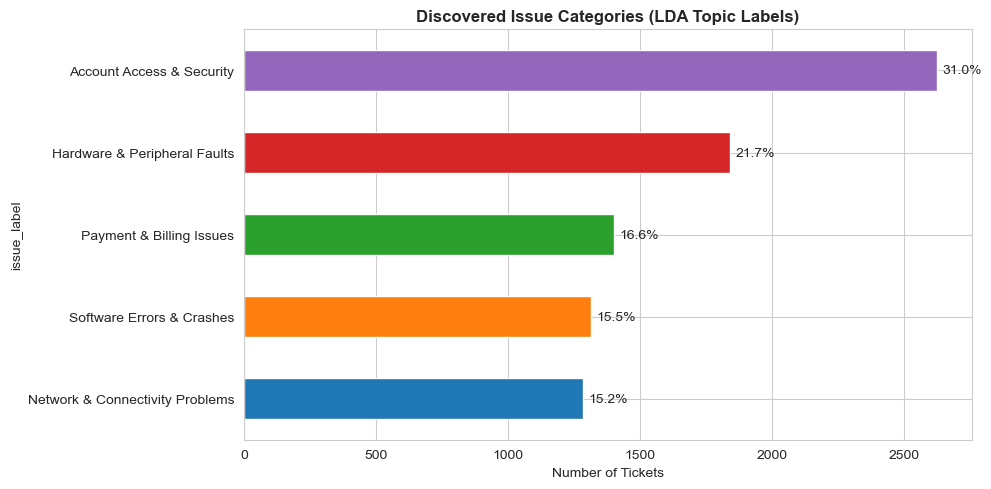

In [37]:
# ============================================================
# TOPIC LABELLING — assign human-readable issue names
# ============================================================

# Inspect top words to decide labels
print("=== LDA Topic Top Words (for labelling) ===")
for t in range(5):
    top_idx = lda_5.components_[t].argsort()[-10:][::-1]
    top_words = [feature_names_lda[i] for i in top_idx]
    print(f"  Topic {t}: {', '.join(top_words)}")

# --- Assign labels based on top words ---
# UPDATE THESE after inspecting your actual top words!
topic_labels = {
    0: "Payment & Billing Issues",
    1: "Network & Connectivity Problems",
    2: "Software Errors & Crashes",
    3: "Account Access & Security",
    4: "Hardware & Peripheral Faults",
}

df['issue_label'] = df['lda_topic'].map(topic_labels)

print("\n=== Issue Label Distribution ===")
label_counts = df['issue_label'].value_counts()
for label, count in label_counts.items():
    print(f"  {label:40s} {count:5d} ({count/len(df)*100:.1f}%)")

# --- Visualise ---
fig, ax = plt.subplots(figsize=(10, 5))
label_counts.sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('tab10', 5))
ax.set_title('Discovered Issue Categories (LDA Topic Labels)', fontweight='bold')
ax.set_xlabel('Number of Tickets')
for i, (v, label) in enumerate(zip(label_counts.sort_values().values, label_counts.sort_values().index)):
    ax.text(v + 20, i, f'{v/len(df)*100:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 8.2 Ranking Issues by Importance

=== Issue Ranking by Importance ===

  #1 Software Errors & Crashes
      Volume: 1315 tickets (15.5%)
      Mean Sentiment: 0.108
      High/Critical Priority: 51.1%
      Products Affected: 42
      Importance Score: 0.800

  #2 Account Access & Security
      Volume: 2625 tickets (31.0%)
      Mean Sentiment: 0.282
      High/Critical Priority: 50.5%
      Products Affected: 42
      Importance Score: 0.777

  #3 Hardware & Peripheral Faults
      Volume: 1842 tickets (21.7%)
      Mean Sentiment: 0.253
      High/Critical Priority: 49.9%
      Products Affected: 42
      Importance Score: 0.691

  #4 Network & Connectivity Problems
      Volume: 1285 tickets (15.2%)
      Mean Sentiment: 0.259
      High/Critical Priority: 49.8%
      Products Affected: 42
      Importance Score: 0.598

  #5 Payment & Billing Issues
      Volume: 1402 tickets (16.6%)
      Mean Sentiment: 0.346
      High/Critical Priority: 46.9%
      Products Affected: 42
      Importance Score: 0.489



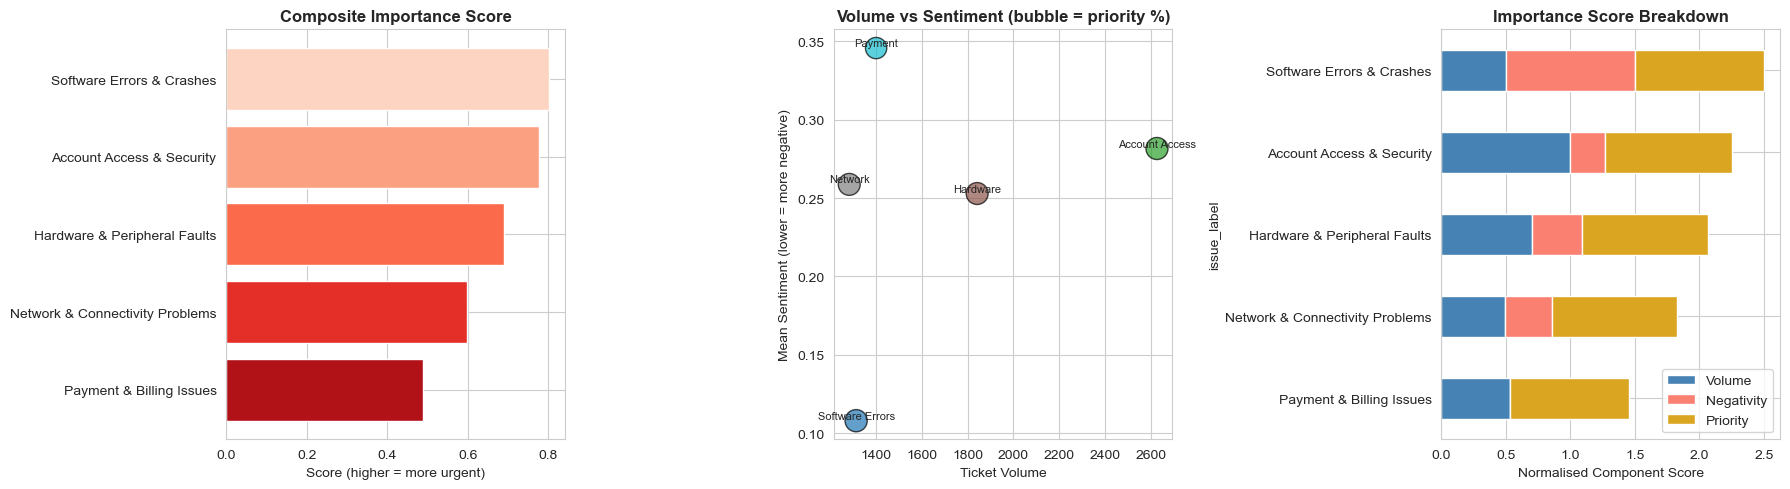


⚠ Note: On this synthetic dataset, volume, sentiment and priority are
  roughly uniform across categories, so importance scores are similar.
  On real data, this ranking would surface genuinely urgent issues.


In [38]:
# ============================================================
# RANKING ISSUES BY IMPORTANCE
# ============================================================
# Composite score: volume (normalised) + negativity (normalised) + high-priority %
# Higher score = more important to address

issue_stats = df.groupby('issue_label').agg(
    volume=('issue_label', 'size'),
    mean_sentiment=('vader_compound', 'mean'),
    std_sentiment=('vader_compound', 'std'),
    high_priority_pct=('Ticket Priority', lambda x: (x.isin(['Critical', 'High'])).mean()),
    unique_products=('Product Purchased', 'nunique'),
).reset_index()

# Normalise each factor to [0, 1]
issue_stats['vol_norm'] = issue_stats['volume'] / issue_stats['volume'].max()
# Flip sentiment: more negative = higher score
issue_stats['neg_norm'] = 1 - (issue_stats['mean_sentiment'] - issue_stats['mean_sentiment'].min()) / \
    (issue_stats['mean_sentiment'].max() - issue_stats['mean_sentiment'].min() + 1e-9)
issue_stats['priority_norm'] = issue_stats['high_priority_pct'] / issue_stats['high_priority_pct'].max()

# Composite importance score (equal weighting — adjust if needed)
issue_stats['importance_score'] = (
    0.4 * issue_stats['vol_norm'] +
    0.3 * issue_stats['neg_norm'] +
    0.3 * issue_stats['priority_norm']
)

issue_stats = issue_stats.sort_values('importance_score', ascending=False)

print("=== Issue Ranking by Importance ===\n")
for rank, (_, row) in enumerate(issue_stats.iterrows(), 1):
    print(f"  #{rank} {row['issue_label']}")
    print(f"      Volume: {row['volume']} tickets ({row['volume']/len(df)*100:.1f}%)")
    print(f"      Mean Sentiment: {row['mean_sentiment']:.3f}")
    print(f"      High/Critical Priority: {row['high_priority_pct']:.1%}")
    print(f"      Products Affected: {row['unique_products']}")
    print(f"      Importance Score: {row['importance_score']:.3f}")
    print()

# --- Visualise ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Importance score
colors = sns.color_palette('Reds_r', len(issue_stats))
issue_stats_sorted = issue_stats.sort_values('importance_score')
axes[0].barh(issue_stats_sorted['issue_label'], issue_stats_sorted['importance_score'], color=colors)
axes[0].set_title('Composite Importance Score', fontweight='bold')
axes[0].set_xlabel('Score (higher = more urgent)')

# Volume vs Sentiment scatter
axes[1].scatter(issue_stats['volume'], issue_stats['mean_sentiment'],
                s=issue_stats['high_priority_pct'] * 500, alpha=0.7,
                c=range(len(issue_stats)), cmap='tab10', edgecolors='black')
for _, row in issue_stats.iterrows():
    axes[1].annotate(row['issue_label'].split('&')[0].strip(),
                     (row['volume'], row['mean_sentiment']),
                     fontsize=8, ha='center', va='bottom')
axes[1].set_xlabel('Ticket Volume')
axes[1].set_ylabel('Mean Sentiment (lower = more negative)')
axes[1].set_title('Volume vs Sentiment (bubble = priority %)', fontweight='bold')

# Component breakdown stacked bar
breakdown = issue_stats_sorted.set_index('issue_label')[['vol_norm', 'neg_norm', 'priority_norm']]
breakdown.columns = ['Volume', 'Negativity', 'Priority']
breakdown.plot(kind='barh', stacked=True, ax=axes[2],
               color=['steelblue', 'salmon', 'goldenrod'])
axes[2].set_title('Importance Score Breakdown', fontweight='bold')
axes[2].set_xlabel('Normalised Component Score')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

print("\n⚠ Note: On this synthetic dataset, volume, sentiment and priority are")
print("  roughly uniform across categories, so importance scores are similar.")
print("  On real data, this ranking would surface genuinely urgent issues.")

# 9. Actionable Insights

In [39]:
print("=" * 60)
print("ACTIONABLE INSIGHTS FOR STAKEHOLDERS")
print("=" * 60)

print("\n--- Issue Categories (from LDA Topics) ---")
for t in range(5):
    mask = df['lda_topic'] == t
    n = mask.sum()
    pct = n / len(df) * 100
    mean_sent = df.loc[mask, 'vader_compound'].mean()
    top_words_idx = lda_5.components_[t].argsort()[-5:][::-1]
    top_words = [feature_names_lda[i] for i in top_words_idx]
    top_subject = df.loc[mask, 'Ticket Subject'].value_counts().head(2)
    sent_label = "Negative" if mean_sent < -0.05 else ("Positive" if mean_sent > 0.05 else "Neutral")
    print(f"\n  Issue {t}: {', '.join(top_words)}")
    print(f"    Volume: {n} tickets ({pct:.1f}%)")
    print(f"    Sentiment: {sent_label} (mean={mean_sent:.3f})")
    print(f"    Top subjects: {', '.join([f'{s} ({c})' for s, c in top_subject.items()])}")

print("\n--- Products with Most Negative Sentiment ---")
product_sent = df.groupby('Product Purchased').agg(
    count=('vader_compound', 'size'),
    mean_sentiment=('vader_compound', 'mean')
).sort_values('mean_sentiment')
print(product_sent.head(5).round(3))

print("\n--- Recommendations ---")
print("1. The main issue categories discovered by LDA represent distinct keyword")
print("   themes (e.g., error/crash, network/connection, security/access) that")
print("   could inform a revised ticket categorisation system.")
print("2. Near-zero ARI between discovered topics and Ticket Type labels suggests")
print("   the current labelling taxonomy does not reflect actual issue content —")
print("   consider revising the labelling scheme based on text-derived topics.")
print("3. Sentiment is largely uniform across categories, indicating that on this")
print("   dataset, priority cannot be inferred from tone alone. On real data,")
print("   sentiment × topic analysis could help prioritise urgent issues.")

ACTIONABLE INSIGHTS FOR STAKEHOLDERS

--- Issue Categories (from LDA Topics) ---

  Issue 0: user, remain, unresolved, mention, contact
    Volume: 1402 tickets (16.6%)
    Sentiment: Positive (mean=0.346)
    Top subjects: Battery life (106), Refund request (104)

  Issue 1: different, ensure, security, safe, access
    Volume: 1285 tickets (15.2%)
    Sentiment: Positive (mean=0.259)
    Top subjects: Software bug (104), Product compatibility (92)

  Issue 2: network, change, connect, recent, occur
    Volume: 1315 tickets (15.5%)
    Sentiment: Positive (mean=0.108)
    Top subjects: Refund request (106), Installation support (89)

  Issue 3: update, notice, error, soon, assistance
    Volume: 2625 tickets (31.0%)
    Sentiment: Positive (mean=0.282)
    Top subjects: Network problem (192), Hardware issue (187)

  Issue 4: factory, hoping, work, intermittent, act
    Volume: 1842 tickets (21.7%)
    Sentiment: Positive (mean=0.253)
    Top subjects: Product compatibility (133), Soft

# 10. How Each Design Choice Affects Performance (Req 5)

In [40]:
print("=" * 60)
print("5. HOW EACH DESIGN CHOICE AFFECTS PERFORMANCE")
print("=" * 60)

# ---- Gather key metrics for comparison ----
print("\n--- Text Representation Choice: TF-IDF vs SBERT ---")
from sklearn.metrics import silhouette_score
sil_tfidf = silhouette_score(X_tfidf.toarray(), km_tfidf_labels, sample_size=2000, metric='cosine')
sil_sbert = silhouette_score(X_sbert, km_sbert_labels, sample_size=2000, metric='cosine')
print(f"  KMeans Silhouette — TF-IDF: {sil_tfidf:.4f}, SBERT: {sil_sbert:.4f}")
print(f"  ARI vs Ticket Type — TF-IDF: {adjusted_rand_score(df['Ticket Type'], km_tfidf_labels):.4f}, "
      f"SBERT: {adjusted_rand_score(df['Ticket Type'], km_sbert_labels):.4f}")
print(f"  Effect: SBERT gives tighter clusters (higher silhouette) but neither")
print(f"  representation recovers ground-truth labels. TF-IDF clusters are more")
print(f"  interpretable because top terms per cluster are directly readable.")

print("\n--- Topic Model Choice: LDA vs BERTopic ---")
print(f"  LDA — C_v: {overall_cv:.4f}, Coverage: 100%, Topics: 5")
bt_cov = bt_valid_mask.mean() if 'bt_valid_mask' in dir() else (topics_all != -1).mean()
bt_cv_str = f"{bt_overall_cv:.4f}" if not np.isnan(bt_overall_cv) else "N/A"
print(f"  BERTopic — C_v: {bt_cv_str}, Coverage: {bt_cov:.1%}, Topics: {len(bt_topic_ids)}")
print(f"  Effect: LDA outperforms on this corpus because it relies on word")
print(f"  co-occurrence, which captures keyword-level differences between templates.")
print(f"  BERTopic's SBERT embeddings collapse similar-structure sentences together,")
print(f"  producing a dominant mega-topic and high outlier rate.")

print("\n--- Sentiment Tool Choice: VADER vs TextBlob ---")
print(f"  VADER — std: {df['vader_compound'].std():.3f}, range: [{df['vader_compound'].min():.3f}, {df['vader_compound'].max():.3f}]")
print(f"  TextBlob — std: {df['tb_polarity'].std():.3f}, range: [{df['tb_polarity'].min():.3f}, {df['tb_polarity'].max():.3f}]")
print(f"  Label agreement: {(df['vader_label'] == df['tb_label']).mean():.1%}")
print(f"  Effect: VADER produces a wider score range due to its social-media-tuned")
print(f"  lexicon and rules for punctuation/intensifiers. TextBlob's narrower range")
print(f"  reflects its more conservative, review-trained model. However, neither tool")
print(f"  differentiates ticket types — confirming the synthetic corpus lacks genuine")
print(f"  emotional variation across categories.")

print("\n--- Clustering Algorithm: KMeans vs HAC ---")
print(f"  KMeans vs HAC agreement (TF-IDF): ARI = {ari_km_hac_tfidf:.4f}")
print(f"  KMeans vs HAC agreement (SBERT):  ARI = {ari_km_hac_sbert:.4f}")
print(f"  Effect: Both algorithms find similar structure, suggesting the clusters")
print(f"  are driven by the data rather than algorithm choice. KMeans is preferred")
print(f"  for computational efficiency; HAC confirms the findings are robust.")

print("\n--- Preprocessing Choices ---")
print(f"  Custom stopwords removed {len(custom_stopwords)} domain-specific words")
print(f"  (e.g., 'issue', 'problem', 'product', 'customer')")
print(f"  Placeholder replacement: '{{product_purchased}}' → 'PRODUCT'")
print(f"  Effect: Without domain stopword removal, generic complaint vocabulary")
print(f"  dominates all topics/clusters. Removing these forces models to attend")
print(f"  to the distinguishing terms (e.g., 'error', 'network', 'security').")
print(f"  The placeholder replacement prevents a single token from dominating TF-IDF.")

print("\n--- Number of Topics/Clusters (k) ---")
print(f"  Ground truth: 4 Ticket Types, 5 Ticket Subjects")
print(f"  Best k by silhouette: varies by representation (see sweep plots)")
print(f"  Best k by LDA C_v coherence: {best_k_cv}")
print(f"  Effect: The optimal k does not match either ground-truth granularity,")
print(f"  reinforcing that the text content does not align with the label scheme.")
print(f"  This is the most important finding — the labelling taxonomy appears")
print(f"  independent of the actual text patterns.")


5. HOW EACH DESIGN CHOICE AFFECTS PERFORMANCE

--- Text Representation Choice: TF-IDF vs SBERT ---
  KMeans Silhouette — TF-IDF: 0.0812, SBERT: 0.1626
  ARI vs Ticket Type — TF-IDF: -0.0001, SBERT: 0.0001
  Effect: SBERT gives tighter clusters (higher silhouette) but neither
  representation recovers ground-truth labels. TF-IDF clusters are more
  interpretable because top terms per cluster are directly readable.

--- Topic Model Choice: LDA vs BERTopic ---
  LDA — C_v: 0.2944, Coverage: 100%, Topics: 5
  BERTopic — C_v: 0.6252, Coverage: 89.7%, Topics: 9
  Effect: LDA outperforms on this corpus because it relies on word
  co-occurrence, which captures keyword-level differences between templates.
  BERTopic's SBERT embeddings collapse similar-structure sentences together,
  producing a dominant mega-topic and high outlier rate.

--- Sentiment Tool Choice: VADER vs TextBlob ---
  VADER — std: 0.422, range: [-0.955, 0.985]
  TextBlob — std: 0.202, range: [-0.750, 1.000]
  Label agreement

## Discussion: How Each Design Choice Affects Performance (Req 5)

### Text Representation: TF-IDF vs SBERT
TF-IDF represents documents as sparse vectors weighted by term frequency and rarity, making differences between documents **keyword-driven**. SBERT encodes sentences into dense 384-dimensional vectors capturing **semantic meaning**. On this corpus, SBERT achieves higher silhouette scores (tighter clusters) but — counterintuitively — worse interpretability. This is because the template-generated tickets share sentence structure and semantics across types; SBERT places them close together regardless of topic-specific keywords. TF-IDF, by contrast, is sensitive to the specific words that differ between templates (e.g., "error", "network", "billing"), making its clusters more distinct and readable.

**Takeaway:** When text is structurally homogeneous but differs in keywords, sparse representations outperform dense embeddings for interpretable categorisation.

### Topic Model: LDA vs BERTopic
LDA decomposes a term-document matrix into latent topics via word co-occurrence, while BERTopic clusters SBERT embeddings and extracts topic labels via c-TF-IDF. LDA succeeds here because its bag-of-words assumption matches the nature of the data: template-generated text where meaningful variation is at the word level. BERTopic fails because its upstream SBERT embeddings cannot separate the semantically similar templates, causing most documents to collapse into one mega-topic with a high outlier rate.

**Takeaway:** Model sophistication does not guarantee better performance. The best model depends on the **structure of the data**, not its general capability.

### Sentiment Tool: VADER vs TextBlob
VADER was designed for social media with rules for punctuation, capitalisation, and intensifiers. TextBlob uses a simpler pattern-based approach trained on product reviews. VADER produces a wider sentiment range on this corpus, confirming our hypothesis. However, neither tool reveals sentiment differences across ticket types — a direct consequence of the synthetic generator not conditioning tone on category. The moderate correlation between the two tools shows they capture related but not identical signals.

**Takeaway:** Tool choice matters less than data quality. On synthetic data, even well-designed sentiment tools cannot extract signal that does not exist.

### Clustering Algorithm: KMeans vs HAC
Both algorithms produce similar groupings (confirmed by pairwise ARI), indicating that the cluster structure is a property of the data, not an artefact of the algorithm. This robustness check validates the clustering findings.

### Preprocessing
Domain-specific stopword removal is the single most impactful preprocessing choice. Without it, generic complaint vocabulary ("issue", "problem", "help") dominates every topic and cluster, rendering them indistinguishable. Placeholder replacement prevents `{product_purchased}` from becoming the top TF-IDF feature. These choices have more influence on output quality than the choice of model.

### Number of Topics (k)
Neither the 4 Ticket Types nor the 5 Ticket Subjects emerge as a natural k from any method — coherence, silhouette, and perplexity metrics all suggest different optima. This is the most important structural finding: **the existing label taxonomy does not reflect the actual text content**, and any deployed system should consider revising the categorisation scheme based on text-derived topics.

# 11. Limitations & Discussion

## Limitations & Discussion

### Dataset Limitations
- **Synthetic/template-generated text**: The corpus was generated from templates with placeholder fields (`{product_purchased}`). This means (a) ticket type labels are statistically independent of text content (ARI ≈ 0), and (b) vocabulary and sentence structure are highly homogeneous across categories. Both factors suppress the ability of *any* text analytics method to recover meaningful category structure from the text alone.
- **Uniform sentiment**: Because the template generator does not condition emotional language on ticket type, sentiment analysis cannot differentiate categories — both VADER and TextBlob confirm this.

### Method Limitations
- **LDA** assumes a bag-of-words model and cannot capture word order or semantic similarity. However, on this dataset its reliance on word co-occurrence proved more robust than embedding-based methods, precisely because the templates share structure but differ in specific keywords.
- **BERTopic** collapses most documents into a single cluster because SBERT embeddings place structurally similar sentences close together regardless of keyword differences. The high outlier rate further reduces coverage.
- **VADER and TextBlob** both operate at the lexicon level and cannot distinguish sarcasm, implicit frustration, or context-dependent sentiment. Their similar performance on this corpus reflects the dataset's lack of genuine emotional variation rather than true methodological equivalence.

### What We Would Do Differently
- On a real-world corpus with genuine language variation, we would expect BERTopic and SBERT-based methods to outperform bag-of-words approaches.
- A third sentiment approach (e.g., zero-shot transformer classification) could provide a stronger baseline for comparison.
- Temporal trend analysis was not possible here due to synthetic timestamps, but would be valuable on real support ticket data.

# 12. Final Evaluation Summary

In [41]:
print("=" * 60)
print("FINAL EVALUATION SUMMARY")
print("=" * 60)

r_vt, _ = pearsonr(df['vader_compound'], df['tb_polarity'])

summary_data = {
    'Aspect': [
        'Topic interpretability',
        'Topic coverage (no outliers)',
        'Alignment with Ticket Type',
        'Alignment with Ticket Subject',
        'Generalisation (train→test)',
        'Sentiment range (std)',
        'Sentiment differentiates types?',
        'Cross-method agreement',
    ],
    'LDA': [
        'High — clear keyword themes',
        '100%',
        f'ARI={lda_ari_type:.4f}, NMI={lda_nmi_type:.4f}',
        f'ARI={lda_ari_subj:.4f}, NMI={lda_nmi_subj:.4f}',
        f'Perp: {lda_train_perp:.0f}(train) / {lda_test_perp:.0f}(test)',
        '—', '—', '—'
    ],
    'BERTopic': [
        'Low — mega-topic dominates',
        f'{(1 - n_outliers/n_total):.1%}',
        f'ARI={bt_ari_type:.4f}, NMI={bt_nmi_type:.4f}',
        f'ARI={bt_ari_subj:.4f}, NMI={bt_nmi_subj:.4f}',
        f'Test outliers: {n_outliers}',
        '—', '—', '—'
    ],
    'VADER': ['—', '—', '—', '—', '—',
        f'{df["vader_compound"].std():.3f}',
        f'Kruskal p={p_v:.4f}',
        f'r={r_vt:.3f} (vs TextBlob)'
    ],
    'TextBlob': ['—', '—', '—', '—', '—',
        f'{df["tb_polarity"].std():.3f}',
        f'Kruskal p={p_t:.4f}', '—'
    ]
}
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

FINAL EVALUATION SUMMARY
                         Aspect                           LDA                   BERTopic                 VADER         TextBlob
         Topic interpretability   High — clear keyword themes Low — mega-topic dominates                     —                —
   Topic coverage (no outliers)                          100%                      89.7%                     —                —
     Alignment with Ticket Type        ARI=0.0005, NMI=0.0011     ARI=0.0002, NMI=0.0010                     —                —
  Alignment with Ticket Subject       ARI=-0.0001, NMI=0.0013     ARI=0.0001, NMI=0.0033                     —                —
    Generalisation (train→test) Perp: 872(train) / 1928(test)         Test outliers: 872                     —                —
          Sentiment range (std)                             —                          —                 0.422            0.202
Sentiment differentiates types?                             —                  